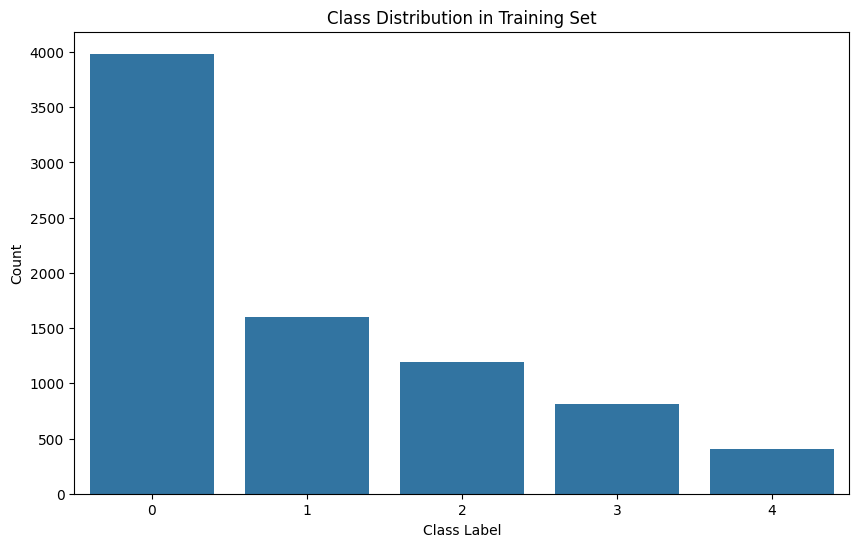

Label
0    3985
1    1604
2    1196
3     809
4     406
Name: count, dtype: int64
--- Train Set ---
Total examples: 8000
Batch Features shape: torch.Size([32, 206])
Batch Labels shape:   torch.Size([32])

--- Test Set ---
Total examples: 2000
Batch Features shape: torch.Size([32, 205])
Batch Labels shape:   torch.Size([32])



In [3]:
# read in packages
import torch
import pandas as pd
import numpy as np
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset, random_split
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
class CSVDataset(Dataset):
    def __init__(self, csv_file_path):
        # Load the data using pandas
        self.df = pd.read_csv(csv_file_path)

        # last column is the label and others are features
        # Convert pandas DataFrame to numpy arrays, then to PyTorch tensors
        self.features = torch.from_numpy(self.df.iloc[:, :-1].values).float()
        self.labels = torch.from_numpy(self.df.iloc[:, -1].values).long()

    def __len__(self):
        # Return the number of rows in the DataFrame
        return len(self.df)

    def __getitem__(self, idx):
        # Return a single sample (features and label) as tensors
        return self.features[idx], self.labels[idx]

# create dataset instances
train_dataset = CSVDataset('/Users/edmundtsou/Desktop/JHU Files/Sophomore/Neural Networks from Scratch/Neural-Network-from-Scratch-Mystery-Project/Data/train.csv')
test_dataset = CSVDataset('/Users/edmundtsou/Desktop/JHU Files/Sophomore/Neural Networks from Scratch/Neural-Network-from-Scratch-Mystery-Project/Data/test.csv')

# check for class imbalances
# Extract labels from the train dataset
train_labels = [label.item() for _, label in train_dataset]

# Create a DataFrame for easier plotting
df_labels = pd.DataFrame(train_labels, columns=['Label'])

# Plot
plt.figure(figsize=(10, 6))
sns.countplot(data=df_labels, x='Label')
plt.title('Class Distribution in Training Set')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.show()

# Print exact counts
print(df_labels['Label'].value_counts().sort_index())

# create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

loaders = [("Train", train_loader), ("Test", test_loader)]

# print dataset info
for loader_name, loader in loaders:
    print(f"--- {loader_name} Set ---")
    print(f"Total examples: {len(loader.dataset)}")
    
    # Check the first batch to get shapes
    for features, labels in loader:
        print(f"Batch Features shape: {features.shape}")
        print(f"Batch Labels shape:   {labels.shape}")
        break 
    print()


Model 1: MLP with Focal Loss
Model 2: MLP with Class-Weighted Cross-Entropy


=== Fold 1/5 | loss=ce ===
Class counts: [3188 1283  957  648  324]
              precision    recall  f1-score   support

           0      0.934     0.940     0.937       797
           1      0.826     0.916     0.869       321
           2      0.865     0.858     0.861       239
           3      0.784     0.677     0.727       161
           4      0.667     0.537     0.595        82

    accuracy                          0.876      1600
   macro avg      0.815     0.785     0.798      1600
weighted avg      0.873     0.876     0.873      1600


=== Fold 2/5 | loss=ce ===
Class counts: [3188 1283  957  647  325]
              precision    recall  f1-score   support

           0      0.925     0.946     0.935       797
           1      0.897     0.891     0.894       321
           2      0.817     0.820     0.818       239
           3      0.868     0.772     0.817       162
           4      0.610     0.617     0.613        81

    accuracy                          0.882    

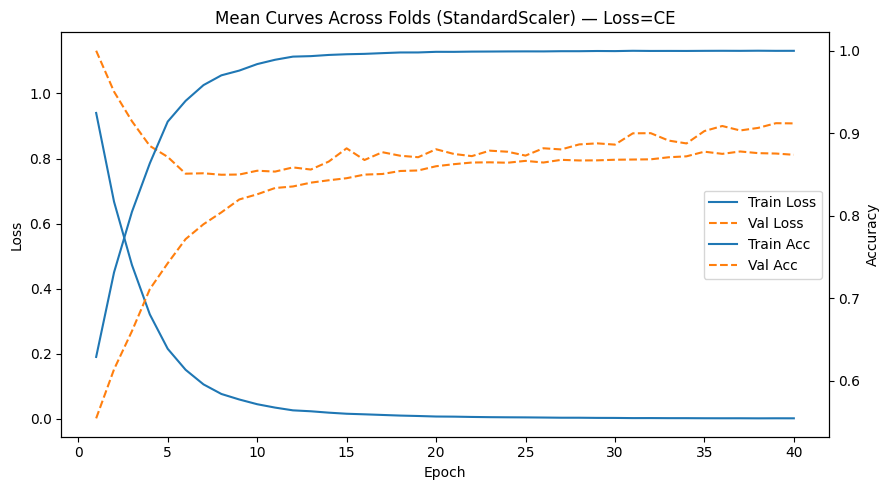


=== Cross-validated performance (StandardScaler, loss=ce) ===
              precision    recall  f1-score   support

           0      0.932     0.934     0.933      3985
           1      0.854     0.884     0.869      1604
           2      0.816     0.849     0.832      1196
           3      0.798     0.748     0.772       809
           4      0.668     0.569     0.614       406

    accuracy                          0.874      8000
   macro avg      0.814     0.797     0.804      8000
weighted avg      0.872     0.874     0.873      8000



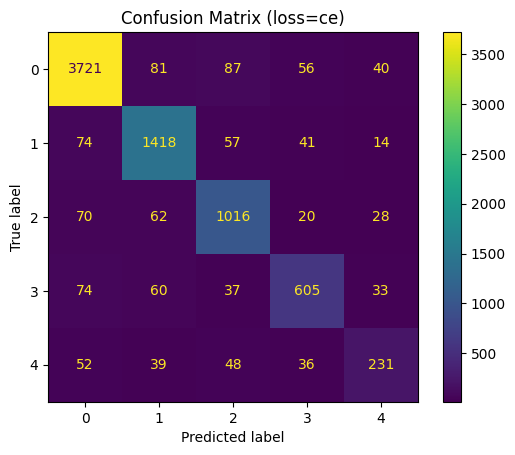


=== Fold 1/5 | loss=focal ===
Class counts: [3188 1283  957  648  324]
              precision    recall  f1-score   support

           0      0.920     0.942     0.931       797
           1      0.858     0.882     0.869       321
           2      0.866     0.841     0.854       239
           3      0.776     0.708     0.740       161
           4      0.653     0.598     0.624        82

    accuracy                          0.874      1600
   macro avg      0.815     0.794     0.804      1600
weighted avg      0.871     0.874     0.872      1600


=== Fold 2/5 | loss=focal ===
Class counts: [3188 1283  957  647  325]
              precision    recall  f1-score   support

           0      0.932     0.932     0.932       797
           1      0.887     0.882     0.884       321
           2      0.846     0.828     0.837       239
           3      0.818     0.802     0.810       162
           4      0.604     0.679     0.640        81

    accuracy                          0.8

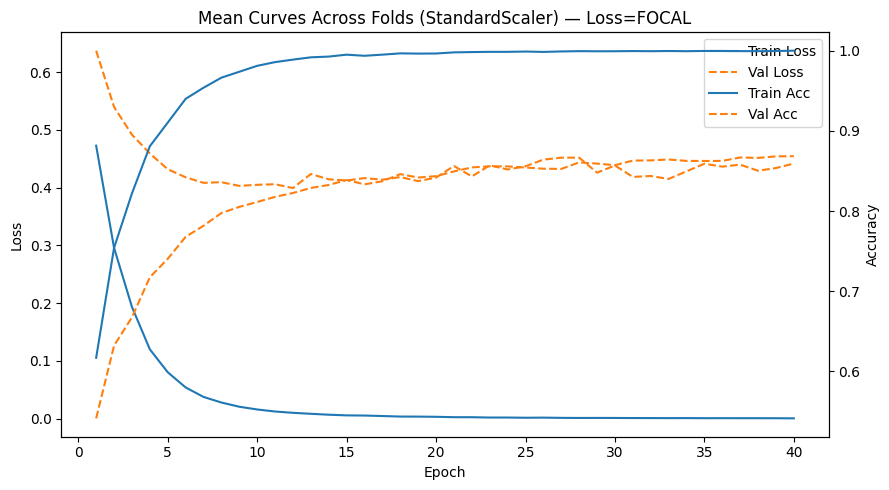


=== Cross-validated performance (StandardScaler, loss=focal) ===
              precision    recall  f1-score   support

           0      0.926     0.930     0.928      3985
           1      0.858     0.880     0.869      1604
           2      0.827     0.823     0.825      1196
           3      0.756     0.754     0.755       809
           4      0.660     0.574     0.614       406

    accuracy                          0.868      8000
   macro avg      0.805     0.792     0.798      8000
weighted avg      0.867     0.868     0.867      8000



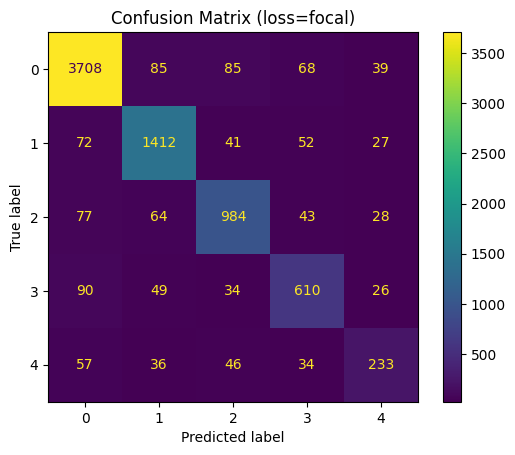

In [28]:
"""
Matched MLP + Stratified K-Fold CV (StandardScaler per fold)
- NO early stopping (always trains full epochs)
- ONLY difference between runs is the loss:
    (A) classic class-weighted cross entropy
    (B) class-weighted focal loss (built on CE)
- Plots:
    Exactly TWO plots total (one per run):
      - Mean train/val loss + mean train/val accuracy across all folds
      - Loss and accuracy share the same figure (two y-axes)
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)
import matplotlib.pyplot as plt


# -----------------------------
# 1) Model
# -----------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, num_classes, hidden=(512, 256), dropout=0.35):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers += [nn.Linear(prev, num_classes)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# -----------------------------
# 2) Dataset wrapper (NumPy -> Torch)
# -----------------------------
class NumpyTabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# -----------------------------
# 3) Helpers
# -----------------------------
def compute_class_weights(y, K, device):
    counts = np.bincount(y, minlength=K)
    weights = counts.sum() / (K * np.maximum(counts, 1))
    return torch.tensor(weights, dtype=torch.float32, device=device), counts


def materialize_numpy(dataset, indices):
    """
    Materialize features/labels to NumPy for StandardScaler.
    Assumes dataset[i] -> (x, y), where x is a CPU tensor/array, y is class index.
    """
    Xs, ys = [], []
    for i in indices:
        x, y = dataset[i]

        # features
        if torch.is_tensor(x):
            if x.ndim > 1:
                x = x.view(-1)
            Xs.append(x.detach().cpu().numpy())
        else:
            x = np.asarray(x).reshape(-1)
            Xs.append(x)

        # label
        if torch.is_tensor(y):
            ys.append(int(y.item()))
        else:
            ys.append(int(y))

    return np.stack(Xs), np.array(ys, dtype=np.int64)


@torch.no_grad()
def predict_loader(model, loader, device="cpu"):
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        pred = torch.argmax(logits, dim=1).detach().cpu().numpy()
        y_pred.append(pred)
        y_true.append(y.numpy())
    return np.concatenate(y_true), np.concatenate(y_pred)


def compute_loss_batch(logits, y, loss_fn_name, class_w, focal_gamma=2.0):
    """
    Returns mean loss over batch (scalar tensor).
    """
    if loss_fn_name == "ce":
        return F.cross_entropy(logits, y, weight=class_w)
    elif loss_fn_name == "focal":
        ce = F.cross_entropy(logits, y, weight=class_w, reduction="none")  # (B,)
        p = torch.softmax(logits, dim=1).gather(1, y.view(-1, 1)).squeeze(1).clamp(1e-6, 1.0)
        return ((1.0 - p) ** focal_gamma * ce).mean()
    else:
        raise ValueError(f"Unknown loss_fn_name: {loss_fn_name}")


@torch.no_grad()
def eval_loss_and_acc(model, loader, device, loss_fn_name, class_w, focal_gamma=2.0):
    """
    Computes mean loss and accuracy over the loader.
    """
    model.eval()
    total_loss = 0.0
    total_n = 0
    all_true, all_pred = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)

        # sum-reduction for correct dataset mean
        if loss_fn_name == "ce":
            loss_sum = F.cross_entropy(logits, y, weight=class_w, reduction="sum")
        else:
            ce = F.cross_entropy(logits, y, weight=class_w, reduction="none")
            p = torch.softmax(logits, dim=1).gather(1, y.view(-1, 1)).squeeze(1).clamp(1e-6, 1.0)
            loss_sum = ((1.0 - p) ** focal_gamma * ce).sum()

        total_loss += float(loss_sum.item())
        total_n += int(y.numel())

        pred = torch.argmax(logits, dim=1)
        all_pred.append(pred.detach().cpu().numpy())
        all_true.append(y.detach().cpu().numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    acc = accuracy_score(y_true, y_pred) if total_n > 0 else 0.0
    mean_loss = total_loss / max(total_n, 1)
    return mean_loss, acc


# -----------------------------
# 4) Plot: ONE figure with loss + accuracy (two axes), averaged over folds
# -----------------------------
def plot_mean_curves_across_folds(histories, loss_name):
    """
    histories: list of dicts, one per fold
      keys: train_loss, val_loss, train_acc, val_acc (each list length=epochs)
    Produces ONE plot (loss + acc in same figure).
    """
    train_loss = np.stack([h["train_loss"] for h in histories])  # (F, E)
    val_loss   = np.stack([h["val_loss"]   for h in histories])
    train_acc  = np.stack([h["train_acc"]  for h in histories])
    val_acc    = np.stack([h["val_acc"]    for h in histories])

    tl = train_loss.mean(axis=0)
    vl = val_loss.mean(axis=0)
    ta = train_acc.mean(axis=0)
    va = val_acc.mean(axis=0)

    epochs = np.arange(1, len(tl) + 1)

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax2 = ax1.twinx()

    # Loss on left axis
    ax1.plot(epochs, tl, label="Train Loss", linestyle="-")
    ax1.plot(epochs, vl, label="Val Loss", linestyle="--")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")

    # Accuracy on right axis
    ax2.plot(epochs, ta, label="Train Acc", linestyle="-")
    ax2.plot(epochs, va, label="Val Acc", linestyle="--")
    ax2.set_ylabel("Accuracy")

    # Unified legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

    plt.title(f"Mean Curves Across Folds (StandardScaler) — Loss={loss_name.upper()}")
    plt.tight_layout()
    plt.show()


# -----------------------------
# 5) Train one fold (NO early stopping)
# -----------------------------
def train_one_fold(
    train_loader,
    val_loader,
    in_dim,
    K,
    class_w,
    device="cpu",
    hidden=(512, 256),
    dropout=0.35,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=40,
    loss_fn_name="ce",     # "ce" or "focal"
    focal_gamma=2.0,
):
    model = MLP(in_dim, K, hidden=hidden, dropout=dropout).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for ep in range(1, epochs + 1):
        model.train()
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = compute_loss_batch(logits, y, loss_fn_name, class_w, focal_gamma)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # log epoch metrics (same for both versions)
        tr_loss, tr_acc = eval_loss_and_acc(model, train_loader, device, loss_fn_name, class_w, focal_gamma)
        va_loss, va_acc = eval_loss_and_acc(model, val_loader, device, loss_fn_name, class_w, focal_gamma)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

    return model, history


# -----------------------------
# 6) Cross-validation runner (StandardScaler per fold)
#     IDENTICAL for CE vs Focal except loss_fn_name (+gamma)
# -----------------------------
def cross_validate_mlp_standardscaler(
    dataset,
    n_splits=5,
    batch_size=128,
    device=None,
    random_state=0,
    epochs=40,
    loss_fn_name="ce",     # "ce" or "focal"
    focal_gamma=2.0,
    hidden=(512, 256),
    dropout=0.35,
    lr=1e-3,
    weight_decay=1e-4,
):
    if device is None:
        device = "mps" if torch.backends.mps.is_available() else "cpu"

    N = len(dataset)
    indices = np.arange(N)

    # labels assumed to be class indices 0..K-1
    y_all = np.array([int(dataset[i][1]) for i in indices], dtype=np.int64)
    K = int(y_all.max()) + 1

    x0, _ = dataset[0]
    if torch.is_tensor(x0):
        in_dim = int(np.prod(x0.shape))
    else:
        in_dim = int(np.prod(np.asarray(x0).shape))

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    all_true, all_pred = [], []
    all_histories = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(indices, y_all), 1):
        print(f"\n=== Fold {fold}/{n_splits} | loss={loss_fn_name} ===")

        # materialize fold to NumPy so StandardScaler can be applied
        X_tr, y_tr = materialize_numpy(dataset, tr_idx)
        X_va, y_va = materialize_numpy(dataset, va_idx)

        scaler = StandardScaler().fit(X_tr)     # fit on train only
        X_tr = scaler.transform(X_tr)
        X_va = scaler.transform(X_va)

        train_ds = NumpyTabularDataset(X_tr, y_tr)
        val_ds = NumpyTabularDataset(X_va, y_va)

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

        class_w, counts = compute_class_weights(y_tr, K, device)
        print("Class counts:", counts)

        model, history = train_one_fold(
            train_loader=train_loader,
            val_loader=val_loader,
            in_dim=in_dim,
            K=K,
            class_w=class_w,
            device=device,
            hidden=hidden,
            dropout=dropout,
            lr=lr,
            weight_decay=weight_decay,
            epochs=epochs,
            loss_fn_name=loss_fn_name,
            focal_gamma=focal_gamma,
        )

        all_histories.append(history)

        # evaluate this fold
        y_t, y_p = predict_loader(model, val_loader, device=device)
        print(classification_report(y_t, y_p, digits=3, zero_division=0))

        all_true.append(y_t)
        all_pred.append(y_p)

    # One plot TOTAL for this run (mean across folds)
    plot_mean_curves_across_folds(all_histories, loss_name=loss_fn_name)

    # aggregate CV performance
    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    print(f"\n=== Cross-validated performance (StandardScaler, loss={loss_fn_name}) ===")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(f"Confusion Matrix (loss={loss_fn_name})")
    plt.show()

    return y_true, y_pred


# ----------------------
# -------
# 7) Run BOTH versions (you will get exactly 2 curve plots total)
# -----------------------------
# 1) Classic class-weighted cross entropy
y_true_ce, y_pred_ce = cross_validate_mlp_standardscaler(
    dataset=train_loader.dataset,
    n_splits=5,
    batch_size=128,
    random_state=0,
    epochs=40,
    loss_fn_name="ce",
)

# 2) Focal loss (same everything else)
y_true_focal, y_pred_focal = cross_validate_mlp_standardscaler(
    dataset=train_loader.dataset,
    n_splits=5,
    batch_size=128,
    random_state=0,
    epochs=40,
    loss_fn_name="focal",
    focal_gamma=2.0,
)


Starting Run A: Cross Entropy...
Fold 1/5 (ce) complete.
Fold 2/5 (ce) complete.
Fold 3/5 (ce) complete.
Fold 4/5 (ce) complete.
Fold 5/5 (ce) complete.


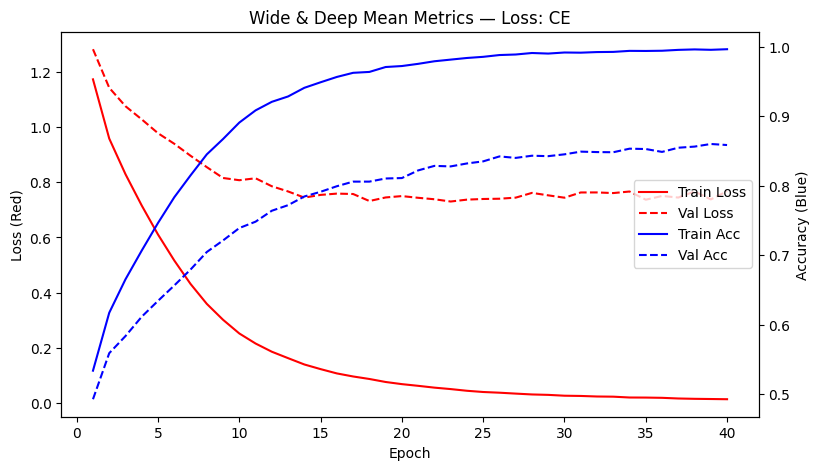


Report (ce):
               precision    recall  f1-score   support

           0      0.923     0.916     0.920      3985
           1      0.845     0.866     0.856      1604
           2      0.808     0.824     0.816      1196
           3      0.755     0.747     0.751       809
           4      0.622     0.584     0.602       406

    accuracy                          0.859      8000
   macro avg      0.791     0.787     0.789      8000
weighted avg      0.858     0.859     0.858      8000



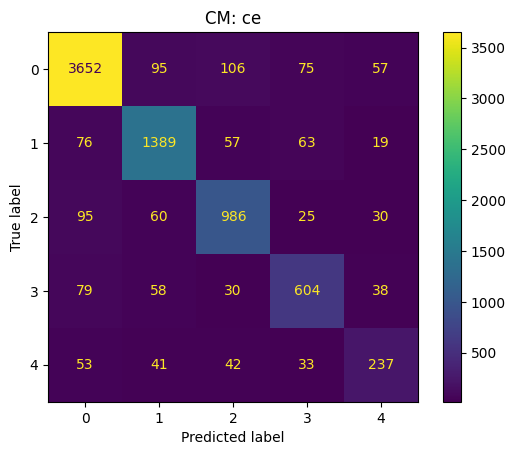


Starting Run B: Focal Loss...
Fold 1/5 (focal) complete.
Fold 2/5 (focal) complete.
Fold 3/5 (focal) complete.
Fold 4/5 (focal) complete.
Fold 5/5 (focal) complete.


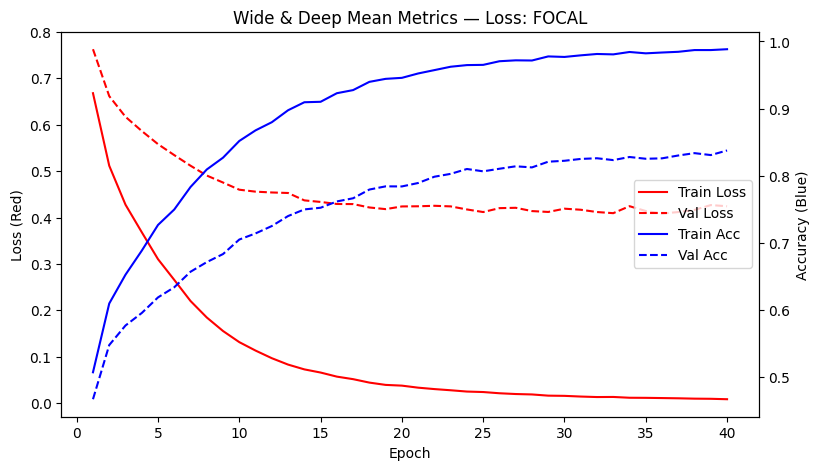


Report (focal):
               precision    recall  f1-score   support

           0      0.920     0.891     0.905      3985
           1      0.824     0.855     0.839      1604
           2      0.784     0.809     0.797      1196
           3      0.690     0.733     0.711       809
           4      0.567     0.534     0.550       406

    accuracy                          0.838      8000
   macro avg      0.757     0.765     0.760      8000
weighted avg      0.839     0.838     0.838      8000



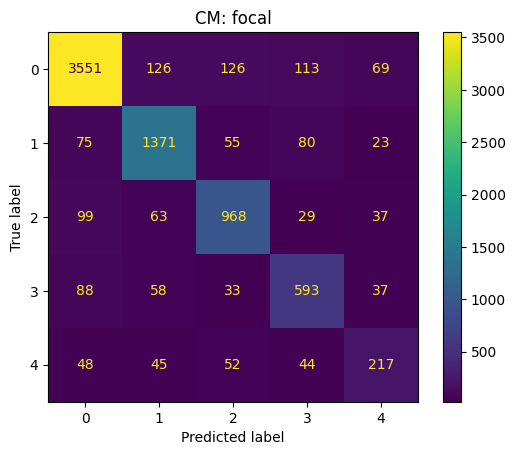

In [25]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)
import matplotlib.pyplot as plt

# -----------------------------
# 1) Architecture: Wide & Deep MLP
# -----------------------------
class WideAndDeepMLP(nn.Module):
    def __init__(self, in_dim, num_classes, hidden_dim=256, dropout=0.35):
        super().__init__()
        
        # Wide Part: Direct linear mapping (Memorization)
        self.wide = nn.Linear(in_dim, num_classes)
        
        # Deep Part: Bottleneck MLP (Generalization)
        self.deep = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.BatchNorm1d(hidden_dim // 4),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout / 2)
        )
        self.deep_out = nn.Linear(hidden_dim // 4, num_classes)

    def forward(self, x):
        wide_out = self.wide(x)
        deep_out = self.deep_out(self.deep(x))
        # Fusion: Combined logits
        return wide_out + deep_out

# -----------------------------
# 2) Dataset and Helpers
# -----------------------------
class NumpyTabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

def compute_class_weights(y, K, device):
    counts = np.bincount(y, minlength=K)
    weights = counts.sum() / (K * np.maximum(counts, 1))
    return torch.tensor(weights, dtype=torch.float32, device=device), counts

def materialize_numpy(dataset, indices):
    Xs, ys = [], []
    for i in indices:
        x, y = dataset[i]
        Xs.append(x.detach().cpu().numpy().flatten())
        ys.append(int(y.item()) if torch.is_tensor(y) else int(y))
    return np.stack(Xs), np.array(ys, dtype=np.int64)

# -----------------------------
# 3) Loss and Evaluation
# -----------------------------
def compute_loss_batch(logits, y, loss_fn_name, class_w, focal_gamma=2.0, reduction='mean'):
    if loss_fn_name == "ce":
        return F.cross_entropy(logits, y, weight=class_w, reduction=reduction)
    elif loss_fn_name == "focal":
        ce = F.cross_entropy(logits, y, weight=class_w, reduction="none")
        p = torch.softmax(logits, dim=1).gather(1, y.view(-1, 1)).squeeze(1).clamp(1e-6, 1.0)
        loss = ((1.0 - p) ** focal_gamma * ce)
        return loss.mean() if reduction == 'mean' else loss.sum()

@torch.no_grad()
def eval_loss_and_acc(model, loader, device, loss_fn_name, class_w, focal_gamma=2.0):
    model.eval()
    total_loss, total_n = 0.0, 0
    all_true, all_pred = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss_sum = compute_loss_batch(logits, y, loss_fn_name, class_w, focal_gamma, reduction='sum')
        total_loss += float(loss_sum.item())
        total_n += int(y.numel())
        all_pred.append(torch.argmax(logits, dim=1).cpu().numpy())
        all_true.append(y.cpu().numpy())
    
    y_true_all = np.concatenate(all_true)
    y_pred_all = np.concatenate(all_pred)
    acc = accuracy_score(y_true_all, y_pred_all) if total_n > 0 else 0.0
    return total_loss / max(total_n, 1), acc

# -----------------------------
# 4) Training and CV Logic
# -----------------------------
def plot_mean_curves(histories, loss_name):
    tl = np.mean([h["train_loss"] for h in histories], axis=0)
    vl = np.mean([h["val_loss"] for h in histories], axis=0)
    ta = np.mean([h["train_acc"] for h in histories], axis=0)
    va = np.mean([h["val_acc"] for h in histories], axis=0)
    epochs = np.arange(1, len(tl) + 1)

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax2 = ax1.twinx()
    ax1.plot(epochs, tl, 'r-', label="Train Loss")
    ax1.plot(epochs, vl, 'r--', label="Val Loss")
    ax2.plot(epochs, ta, 'b-', label="Train Acc")
    ax2.plot(epochs, va, 'b--', label="Val Acc")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss (Red)"); ax2.set_ylabel("Accuracy (Blue)")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
    plt.title(f"Wide & Deep Mean Metrics — Loss: {loss_name.upper()}")
    plt.show()

def cross_validate(dataset, loss_fn_name, epochs=40):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    indices = np.arange(len(dataset))
    y_all = np.array([int(dataset[i][1]) for i in indices])
    K = int(y_all.max()) + 1
    in_dim = dataset[0][0].numel()

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    all_true, all_pred, histories = [], [], []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(indices, y_all), 1):
        # Data prep
        X_tr_raw, y_tr = materialize_numpy(dataset, tr_idx)
        X_va_raw, y_va = materialize_numpy(dataset, va_idx)
        scaler = StandardScaler().fit(X_tr_raw)
        X_tr, X_va = scaler.transform(X_tr_raw), scaler.transform(X_va_raw)

        train_loader = DataLoader(NumpyTabularDataset(X_tr, y_tr), batch_size=128, shuffle=True)
        val_loader = DataLoader(NumpyTabularDataset(X_va, y_va), batch_size=128, shuffle=False)
        
        cw, _ = compute_class_weights(y_tr, K, device)
        model = WideAndDeepMLP(in_dim, K).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=5e-4)
        
        # Track progress
        fold_hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

        for ep in range(epochs):
            model.train()
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = compute_loss_batch(logits, y, loss_fn_name, cw)
                optimizer.zero_grad(); loss.backward(); optimizer.step()

            # Record metrics
            tl, ta = eval_loss_and_acc(model, train_loader, device, loss_fn_name, cw)
            vl, va = eval_loss_and_acc(model, val_loader, device, loss_fn_name, cw)
            fold_hist["train_loss"].append(tl); fold_hist["val_loss"].append(vl)
            fold_hist["train_acc"].append(ta); fold_hist["val_acc"].append(va)

        histories.append(fold_hist)
        
        # Final fold prediction
        model.eval()
        with torch.no_grad():
            X_va_t = torch.from_numpy(X_va.astype(np.float32)).to(device)
            fold_preds = torch.argmax(model(X_va_t), dim=1).cpu().numpy()
            all_true.append(y_va); all_pred.append(fold_preds)
        print(f"Fold {fold}/5 ({loss_fn_name}) complete.")

    plot_mean_curves(histories, loss_fn_name)
    y_true, y_pred = np.concatenate(all_true), np.concatenate(all_pred)
    print(f"\nReport ({loss_fn_name}):\n", classification_report(y_true, y_pred, digits=3))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred)).plot()
    plt.title(f"CM: {loss_fn_name}")
    plt.show()

# -----------------------------
# Main Execution
# -----------------------------
if __name__ == "__main__":
    # Assumes train_loader.dataset exists from your previous code
    print("Starting Run A: Cross Entropy...")
    cross_validate(train_loader.dataset, loss_fn_name="ce")
    
    print("\nStarting Run B: Focal Loss...")
    cross_validate(train_loader.dataset, loss_fn_name="focal")

Model 3: two_stage_predict

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
)
import matplotlib.pyplot as plt

# -----------------------------
# 1) Model with Batch Normalization
# -----------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=(512, 256), dropout=0.35):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),  # Normalizes across the batch for stable training
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            prev = h
        layers += [nn.Linear(prev, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# -----------------------------
# 2) Dataset and Utility Functions
# -----------------------------
class NumpyTabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def get_labels_array(dataset):
    return np.array([int(dataset[i][1]) for i in range(len(dataset))], dtype=np.int64)

def materialize_numpy(dataset, indices):
    Xs, ys = [], []
    for i in indices:
        x, y = dataset[i]
        x = x.view(-1) if torch.is_tensor(x) and x.ndim > 1 else np.asarray(x).reshape(-1)
        Xs.append(x.detach().cpu().numpy() if torch.is_tensor(x) else x)
        ys.append(int(y.item()) if torch.is_tensor(y) else int(y))
    return np.stack(Xs), np.array(ys, dtype=np.int64)

# -----------------------------
# 3) Plotting Helper
# -----------------------------
def plot_mean_curves_across_folds(histories, title):
    tl = np.stack([h["train_loss"] for h in histories]).mean(axis=0)
    vl = np.stack([h["val_loss"] for h in histories]).mean(axis=0)
    ta = np.stack([h["train_acc"] for h in histories]).mean(axis=0)
    va = np.stack([h["val_acc"] for h in histories]).mean(axis=0)
    epochs = np.arange(1, len(tl) + 1)

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax2 = ax1.twinx()
    ax1.plot(epochs, tl, 'r-', label="Train Loss")
    ax1.plot(epochs, vl, 'r--', label="Val Loss")
    ax1.set_ylabel("Loss", color='r')
    ax2.plot(epochs, ta, 'b-', label="Train Acc")
    ax2.plot(epochs, va, 'b--', label="Val Acc")
    ax2.set_ylabel("Accuracy", color='b')
    ax1.set_xlabel("Epoch")
    
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="best")
    plt.title(title)
    plt.show()

# -----------------------------
# 4) Training Logic
# -----------------------------
@torch.no_grad()
def eval_loss_acc(model, loader, device, task_type='binary', weight=None):
    model.eval()
    total_loss, total_n = 0.0, 0
    all_true, all_pred = [], []
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if task_type == 'binary':
            y_task = (y == 4).float()
            logits = model(x).squeeze(1)
            loss = F.binary_cross_entropy_with_logits(logits, y_task, pos_weight=weight, reduction='sum')
            pred = (torch.sigmoid(logits) >= 0.5).long()
        else:
            mask = (y != 4)
            if mask.sum() == 0: continue
            x, y_task = x[mask], y[mask]
            logits = model(x)
            loss = F.cross_entropy(logits, y_task, weight=weight, reduction='sum')
            pred = torch.argmax(logits, dim=1)

        total_loss += float(loss.item())
        total_n += int(y_task.numel())
        all_true.append(y_task.cpu().numpy())
        all_pred.append(pred.cpu().numpy())

    return total_loss / max(total_n, 1), accuracy_score(np.concatenate(all_true), np.concatenate(all_pred))

def train_fold_stages(train_loader, val_loader, in_dim, device, epochs):
    # Stage A: Binary
    pos = sum([(y == 4).sum().item() for _, y in train_loader])
    neg = sum([(y != 4).sum().item() for _, y in train_loader])
    pos_w = torch.tensor([neg / max(pos, 1)], device=device)
    
    modelA = MLP(in_dim, 1).to(device)
    optA = torch.optim.AdamW(modelA.parameters(), lr=1e-3, weight_decay=1e-4)
    histA = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    # Stage B: Multiclass (0-3)
    y_train_03 = np.concatenate([y[y != 4].numpy() for _, y in train_loader])
    counts = np.bincount(y_train_03.astype(int), minlength=4)
    cw_03 = torch.tensor(counts.sum() / (4 * np.maximum(counts, 1)), dtype=torch.float32, device=device)
    
    modelB = MLP(in_dim, 4).to(device)
    optB = torch.optim.AdamW(modelB.parameters(), lr=1e-3, weight_decay=1e-4)
    histB = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for ep in range(epochs):
        # Training Stage A
        modelA.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            loss = F.binary_cross_entropy_with_logits(modelA(x).squeeze(1), (y == 4).float(), pos_weight=pos_w)
            optA.zero_grad(); loss.backward(); optA.step()
        
        # Training Stage B
        modelB.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            mask = (y != 4)
            if mask.sum() > 0:
                loss = F.cross_entropy(modelB(x[mask]), y[mask], weight=cw_03)
                optB.zero_grad(); loss.backward(); optB.step()

        # Log Metrics
        l_a, a_a = eval_loss_acc(modelA, train_loader, device, 'binary', pos_w)
        vl_a, va_a = eval_loss_acc(modelA, val_loader, device, 'binary', pos_w)
        histA["train_loss"].append(l_a); histA["val_loss"].append(vl_a)
        histA["train_acc"].append(a_a); histA["val_acc"].append(va_a)

        l_b, a_b = eval_loss_acc(modelB, train_loader, device, 'multi', cw_03)
        vl_b, va_b = eval_loss_acc(modelB, val_loader, device, 'multi', cw_03)
        histB["train_loss"].append(l_b); histB["val_loss"].append(vl_b)
        histB["train_acc"].append(a_b); histB["val_acc"].append(va_b)

    return modelA, modelB, histA, histB

# -----------------------------
# 5) Main CV Runner
# -----------------------------
def cross_validate_two_stage(dataset, n_splits=5, epochs=40):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    y_all = get_labels_array(dataset)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    
    all_true, all_pred, hA, hB = [], [], [], []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(np.zeros(len(y_all)), y_all), 1):
        print(f"=== Fold {fold} ===")
        X_tr, y_tr = materialize_numpy(dataset, tr_idx)
        X_va, y_va = materialize_numpy(dataset, va_idx)
        
        scaler = StandardScaler().fit(X_tr)
        X_tr, X_va = scaler.transform(X_tr), scaler.transform(X_va)
        
        # Use drop_last=True for BatchNorm stability
        tr_loader = DataLoader(NumpyTabularDataset(X_tr, y_tr), batch_size=128, shuffle=True, drop_last=True)
        va_loader = DataLoader(NumpyTabularDataset(X_va, y_va), batch_size=128, shuffle=False)

        mA, mB, fA, fB = train_fold_stages(tr_loader, va_loader, X_tr.shape[1], device, epochs)
        hA.append(fA); hB.append(fB)

        # Inference with Threshold Tuning
        mA.eval(); mB.eval()
        with torch.no_grad():
            X_va_t = torch.from_numpy(X_va.astype(np.float32)).to(device)
            p4 = torch.sigmoid(mA(X_va_t).squeeze(1)).cpu().numpy()
            p03 = torch.softmax(mB(X_va_t), dim=1).cpu().numpy()
            
            best_t, best_f1 = 0.5, -1
            for t in np.linspace(0.1, 0.9, 9):
                preds = np.argmax(p03, axis=1)
                preds[p4 >= t] = 4
                f1 = f1_score(y_va, preds, average='macro')
                if f1 > best_f1: best_f1, best_t = f1, t
            
            final_preds = np.argmax(p03, axis=1)
            final_preds[p4 >= best_t] = 4
            all_true.append(y_va); all_pred.append(final_preds)

    plot_mean_curves_across_folds(hA, "Stage A (Binary) - Mean Metrics")
    plot_mean_curves_across_folds(hB, "Stage B (Multi) - Mean Metrics")
    
    y_true, y_pred = np.concatenate(all_true), np.concatenate(all_pred)
    print("\nReport:\n", classification_report(y_true, y_pred, digits=3))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    plt.show()

if __name__ == "__main__":
    # Assumes train_loader.dataset is available in environment
    cross_validate_two_stage(train_loader.dataset)


=== Fold 1/5 ===


KeyboardInterrupt: 

Model 4: MLP1 trying to prevent overfitting with heavy regularization


=== Fold 1/5 | CE + early stop ===
Class counts: [3188 1283  957  648  324]
              precision    recall  f1-score   support

           0      0.923     0.883     0.903       797
           1      0.840     0.854     0.847       321
           2      0.803     0.820     0.812       239
           3      0.670     0.733     0.700       161
           4      0.516     0.573     0.543        82

    accuracy                          0.837      1600
   macro avg      0.751     0.773     0.761      1600
weighted avg      0.842     0.837     0.839      1600


=== Fold 2/5 | CE + early stop ===
Class counts: [3188 1283  957  647  325]
              precision    recall  f1-score   support

           0      0.931     0.885     0.907       797
           1      0.843     0.872     0.858       321
           2      0.777     0.774     0.776       239
           3      0.723     0.790     0.755       162
           4      0.542     0.642     0.588        81

    accuracy                   

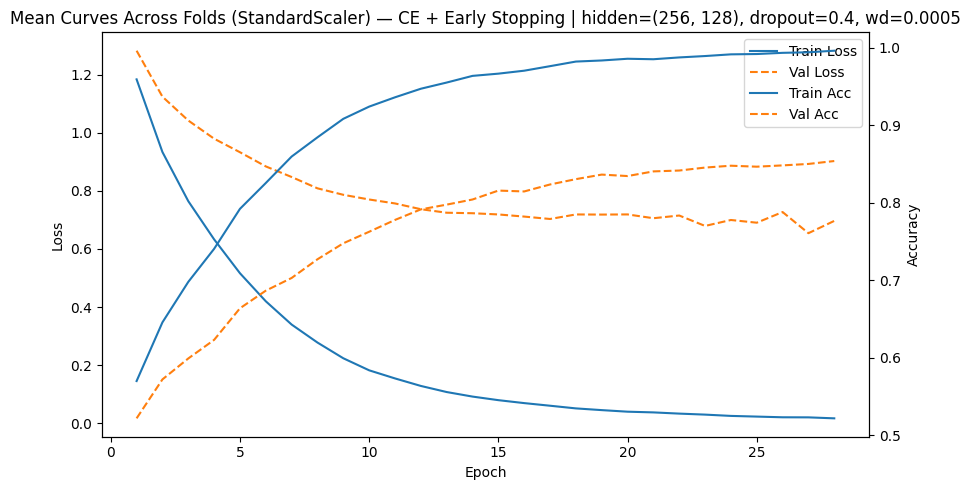


=== Cross-validated performance (StandardScaler, CE + early stopping) ===
              precision    recall  f1-score   support

           0      0.929     0.883     0.906      3985
           1      0.827     0.860     0.843      1604
           2      0.780     0.805     0.793      1196
           3      0.696     0.760     0.727       809
           4      0.564     0.596     0.580       406

    accuracy                          0.840      8000
   macro avg      0.759     0.781     0.770      8000
weighted avg      0.844     0.840     0.842      8000



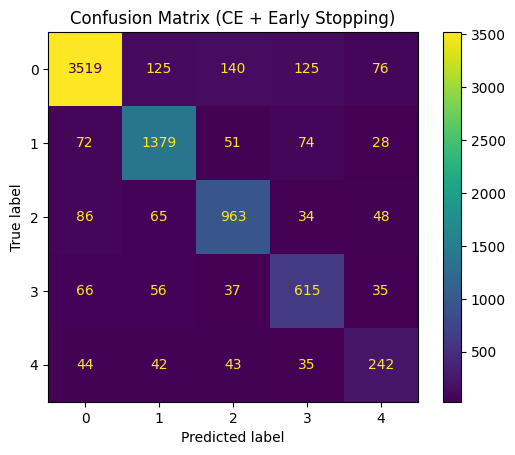

In [31]:
"""
MLP + Stratified K-Fold CV (StandardScaler per fold)
- CLASS-WEIGHTED CROSS ENTROPY ONLY (NO focal anywhere)
- Early stopping (per fold) + best checkpoint restore
- Reduced model capacity + increased dropout + higher weight decay
- Plots: ONE plot total (mean train/val loss + mean train/val accuracy across folds)
  Note: folds may stop at different epochs; we NaN-pad and take nanmean.
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)
import matplotlib.pyplot as plt


# -----------------------------
# 1) Model (reduced capacity + increased dropout)
# -----------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, num_classes, hidden=(256, 128), dropout=0.40):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers += [nn.Linear(prev, num_classes)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# -----------------------------
# 2) Dataset wrapper (NumPy -> Torch)
# -----------------------------
class NumpyTabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# -----------------------------
# 3) Helpers
# -----------------------------
def compute_class_weights(y, K, device):
    counts = np.bincount(y, minlength=K)
    weights = counts.sum() / (K * np.maximum(counts, 1))
    return torch.tensor(weights, dtype=torch.float32, device=device), counts


def materialize_numpy(dataset, indices):
    """
    Materialize features/labels to NumPy for StandardScaler.
    Assumes dataset[i] -> (x, y), where x is CPU tensor/array, y is class index.
    """
    Xs, ys = [], []
    for i in indices:
        x, y = dataset[i]

        # features
        if torch.is_tensor(x):
            if x.ndim > 1:
                x = x.view(-1)
            Xs.append(x.detach().cpu().numpy())
        else:
            Xs.append(np.asarray(x).reshape(-1))

        # label
        ys.append(int(y.item()) if torch.is_tensor(y) else int(y))

    return np.stack(Xs), np.array(ys, dtype=np.int64)


@torch.no_grad()
def predict_loader(model, loader, device="cpu"):
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        pred = torch.argmax(logits, dim=1).detach().cpu().numpy()
        y_pred.append(pred)
        y_true.append(y.numpy())
    return np.concatenate(y_true), np.concatenate(y_pred)


@torch.no_grad()
def eval_loss_and_acc(model, loader, device, class_w, label_smoothing=0.0):
    """
    Mean CE loss (per example) + accuracy over loader.
    """
    model.eval()
    total_loss = 0.0
    total_n = 0
    all_true, all_pred = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)

        loss_sum = F.cross_entropy(
            logits, y, weight=class_w, reduction="sum", label_smoothing=label_smoothing
        )
        total_loss += float(loss_sum.item())
        total_n += int(y.numel())

        pred = torch.argmax(logits, dim=1)
        all_pred.append(pred.detach().cpu().numpy())
        all_true.append(y.detach().cpu().numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    mean_loss = total_loss / max(total_n, 1)
    acc = accuracy_score(y_true, y_pred) if total_n > 0 else 0.0
    return mean_loss, acc


# -----------------------------
# 4) Plot mean curves across folds (handles different early-stop lengths)
# -----------------------------
def plot_mean_curves_across_folds(histories, title):
    """
    histories: list of dicts (one per fold) with variable-length lists.
      keys: train_loss, val_loss, train_acc, val_acc
    We NaN-pad to max_len then nanmean across folds.
    """
    max_len = max(len(h["train_loss"]) for h in histories)

    def pad(arr, L):
        out = np.full(L, np.nan, dtype=np.float64)
        out[: len(arr)] = np.asarray(arr, dtype=np.float64)
        return out

    tl = np.stack([pad(h["train_loss"], max_len) for h in histories])
    vl = np.stack([pad(h["val_loss"],   max_len) for h in histories])
    ta = np.stack([pad(h["train_acc"],  max_len) for h in histories])
    va = np.stack([pad(h["val_acc"],    max_len) for h in histories])

    tl_m = np.nanmean(tl, axis=0)
    vl_m = np.nanmean(vl, axis=0)
    ta_m = np.nanmean(ta, axis=0)
    va_m = np.nanmean(va, axis=0)

    epochs = np.arange(1, max_len + 1)

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax2 = ax1.twinx()

    ax1.plot(epochs, tl_m, label="Train Loss", linestyle="-")
    ax1.plot(epochs, vl_m, label="Val Loss", linestyle="--")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")

    ax2.plot(epochs, ta_m, label="Train Acc", linestyle="-")
    ax2.plot(epochs, va_m, label="Val Acc", linestyle="--")
    ax2.set_ylabel("Accuracy")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

    plt.title(title)
    plt.tight_layout()
    plt.show()


# -----------------------------
# 5) Train one fold (WITH early stopping)
# -----------------------------
def train_one_fold(
    train_loader,
    val_loader,
    in_dim,
    K,
    class_w,
    device="cpu",
    hidden=(256, 128),       # reduced capacity
    dropout=0.40,            # increased dropout
    lr=1e-3,
    weight_decay=5e-4,       # increased weight decay
    epochs=40,
    patience=5,
    min_delta=1e-4,
    label_smoothing=0.0,     # optional; keep 0.0 since you didn't ask for it
):
    model = MLP(in_dim, K, hidden=hidden, dropout=dropout).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    best_val_loss = float("inf")
    best_state = None
    bad = 0

    for ep in range(1, epochs + 1):
        model.train()
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = F.cross_entropy(
                logits, y, weight=class_w, label_smoothing=label_smoothing
            )

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # epoch metrics
        tr_loss, tr_acc = eval_loss_and_acc(model, train_loader, device, class_w, label_smoothing)
        va_loss, va_acc = eval_loss_and_acc(model, val_loader, device, class_w, label_smoothing)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        # early stopping on validation loss (lower is better)
        if va_loss < best_val_loss - min_delta:
            best_val_loss = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


# -----------------------------
# 6) Cross-validation runner (StandardScaler per fold)
# -----------------------------
def cross_validate_mlp_standardscaler(
    dataset,
    n_splits=5,
    batch_size=128,
    device=None,
    random_state=0,
    epochs=40,
    # tuned anti-overfit defaults (from your request)
    hidden=(256, 128),
    dropout=0.40,
    weight_decay=5e-4,
    patience=5,
    min_delta=1e-4,
):
    if device is None:
        device = "mps" if torch.backends.mps.is_available() else "cpu"

    N = len(dataset)
    indices = np.arange(N)

    y_all = np.array([int(dataset[i][1]) for i in indices], dtype=np.int64)
    K = int(y_all.max()) + 1

    x0, _ = dataset[0]
    in_dim = int(np.prod(x0.shape)) if torch.is_tensor(x0) else int(np.prod(np.asarray(x0).shape))

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    all_true, all_pred = [], []
    all_histories = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(indices, y_all), 1):
        print(f"\n=== Fold {fold}/{n_splits} | CE + early stop ===")

        # StandardScaler per fold
        X_tr, y_tr = materialize_numpy(dataset, tr_idx)
        X_va, y_va = materialize_numpy(dataset, va_idx)

        scaler = StandardScaler().fit(X_tr)
        X_tr = scaler.transform(X_tr)
        X_va = scaler.transform(X_va)

        train_ds = NumpyTabularDataset(X_tr, y_tr)
        val_ds = NumpyTabularDataset(X_va, y_va)

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

        class_w, counts = compute_class_weights(y_tr, K, device)
        print("Class counts:", counts)

        model, history = train_one_fold(
            train_loader=train_loader,
            val_loader=val_loader,
            in_dim=in_dim,
            K=K,
            class_w=class_w,
            device=device,
            hidden=hidden,
            dropout=dropout,
            weight_decay=weight_decay,
            epochs=epochs,
            patience=patience,
            min_delta=min_delta,
        )

        all_histories.append(history)

        y_t, y_p = predict_loader(model, val_loader, device=device)
        print(classification_report(y_t, y_p, digits=3, zero_division=0))

        all_true.append(y_t)
        all_pred.append(y_p)

    # ONE plot total (mean curves across folds)
    plot_mean_curves_across_folds(
        all_histories,
        title=f"Mean Curves Across Folds (StandardScaler) — CE + Early Stopping | hidden={hidden}, dropout={dropout}, wd={weight_decay}",
    )

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    print("\n=== Cross-validated performance (StandardScaler, CE + early stopping) ===")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title("Confusion Matrix (CE + Early Stopping)")
    plt.show()

    return y_true, y_pred


# -----------------------------
# 7) Run
# -----------------------------
# dataset must return (x, y) with y as class index
y_true, y_pred = cross_validate_mlp_standardscaler(
    dataset=train_loader.dataset,
    n_splits=5,
    batch_size=128,
    random_state=0,
    epochs=40,
    hidden=(256, 128),     # reduced capacity
    dropout=0.40,          # increased dropout
    weight_decay=5e-4,     # increased weight decay
    patience=5,            # early stopping
    min_delta=1e-4,
)


Model 5: light regularization


=== Fold 1/5 | CE (label_smoothing) + early stop on macro-F1 ===
Class counts: [3188 1283  957  648  324]
              precision    recall  f1-score   support

           0      0.943     0.932     0.938       797
           1      0.899     0.888     0.893       321
           2      0.871     0.874     0.873       239
           3      0.740     0.795     0.766       161
           4      0.695     0.695     0.695        82

    accuracy                          0.889      1600
   macro avg      0.830     0.837     0.833      1600
weighted avg      0.890     0.889     0.889      1600


=== Fold 2/5 | CE (label_smoothing) + early stop on macro-F1 ===
Class counts: [3188 1283  957  647  325]
              precision    recall  f1-score   support

           0      0.955     0.911     0.933       797
           1      0.850     0.897     0.873       321
           2      0.817     0.858     0.837       239
           3      0.810     0.840     0.824       162
           4      0.695   

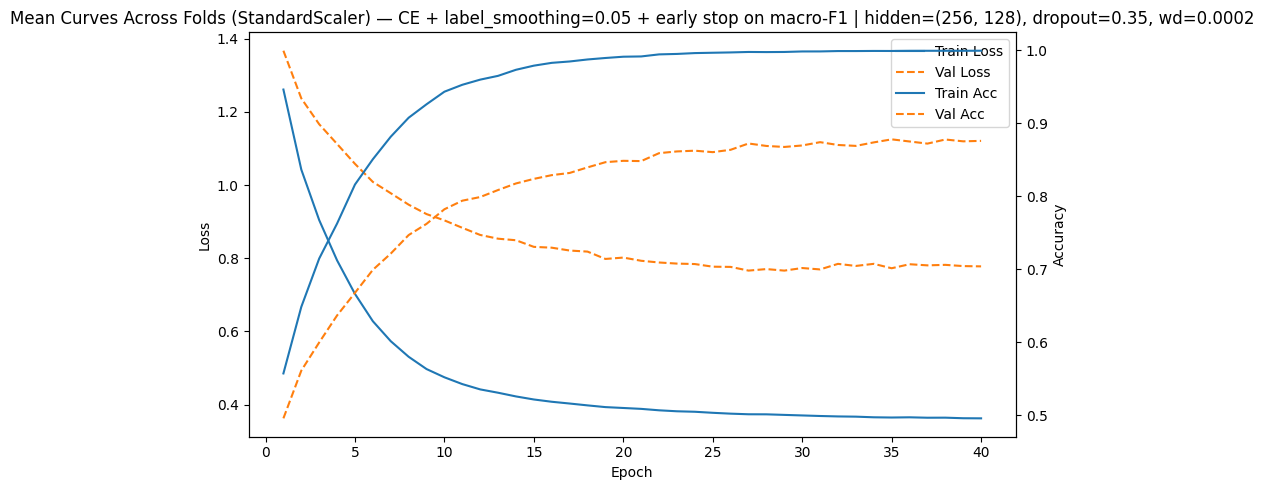


=== Cross-validated performance (StandardScaler, CE + light regularization) ===
              precision    recall  f1-score   support

           0      0.947     0.919     0.933      3985
           1      0.866     0.882     0.874      1604
           2      0.833     0.862     0.847      1196
           3      0.763     0.810     0.786       809
           4      0.677     0.665     0.671       406

    accuracy                          0.879      8000
   macro avg      0.817     0.828     0.822      8000
weighted avg      0.881     0.879     0.880      8000



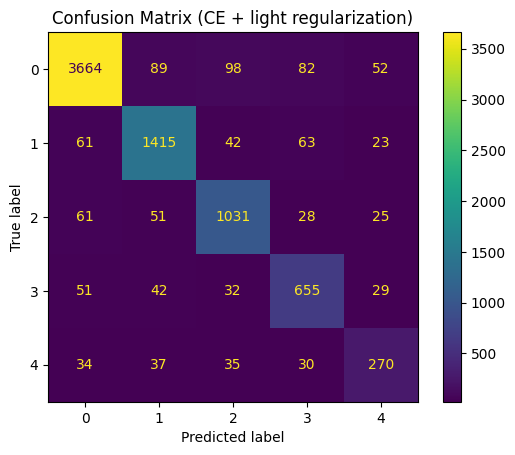

In [30]:
"""
Light-regularization MLP + Stratified K-Fold CV (StandardScaler per fold)

What this does:
- StandardScaler per fold (fit on TRAIN fold only)
- Class-weighted Cross Entropy ONLY (no focal anywhere)
- Light regularization (as discussed):
    hidden = (256, 128)
    dropout = 0.35
    weight_decay = 2e-4
- Label smoothing (helps overconfidence / val-loss drift): label_smoothing = 0.05
- Early stopping on VALIDATION MACRO-F1 (better aligned with imbalance than val loss)
- Plots: ONE plot total (mean train/val loss + mean train/val accuracy across folds)
  Note: folds stop at different epochs; we NaN-pad and nanmean across folds.

Assumptions:
- dataset[i] -> (x, y)
- x is a CPU tensor/array; y is scalar class index 0..K-1
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
)
import matplotlib.pyplot as plt


# -----------------------------
# 1) Model (light regularization)
# -----------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, num_classes, hidden=(256, 128), dropout=0.35):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers += [nn.Linear(prev, num_classes)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# -----------------------------
# 2) Dataset wrapper (NumPy -> Torch)
# -----------------------------
class NumpyTabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# -----------------------------
# 3) Helpers
# -----------------------------
def compute_class_weights(y, K, device):
    counts = np.bincount(y, minlength=K)
    weights = counts.sum() / (K * np.maximum(counts, 1))
    return torch.tensor(weights, dtype=torch.float32, device=device), counts


def materialize_numpy(dataset, indices):
    """
    Materialize features/labels to NumPy for StandardScaler.
    Assumes dataset[i] -> (x, y), where x is CPU tensor/array, y is class index.
    """
    Xs, ys = [], []
    for i in indices:
        x, y = dataset[i]

        # features
        if torch.is_tensor(x):
            if x.ndim > 1:
                x = x.view(-1)
            Xs.append(x.detach().cpu().numpy())
        else:
            Xs.append(np.asarray(x).reshape(-1))

        # label
        ys.append(int(y.item()) if torch.is_tensor(y) else int(y))

    return np.stack(Xs), np.array(ys, dtype=np.int64)


@torch.no_grad()
def predict_loader(model, loader, device="cpu"):
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        pred = torch.argmax(logits, dim=1).detach().cpu().numpy()
        y_pred.append(pred)
        y_true.append(y.numpy())
    return np.concatenate(y_true), np.concatenate(y_pred)


@torch.no_grad()
def eval_loss_and_acc(model, loader, device, class_w, label_smoothing=0.05):
    """
    Mean CE loss (per example) + accuracy over loader.
    """
    model.eval()
    total_loss = 0.0
    total_n = 0
    all_true, all_pred = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)

        loss_sum = F.cross_entropy(
            logits,
            y,
            weight=class_w,
            reduction="sum",
            label_smoothing=label_smoothing,
        )
        total_loss += float(loss_sum.item())
        total_n += int(y.numel())

        pred = torch.argmax(logits, dim=1)
        all_pred.append(pred.detach().cpu().numpy())
        all_true.append(y.detach().cpu().numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    mean_loss = total_loss / max(total_n, 1)
    acc = accuracy_score(y_true, y_pred) if total_n > 0 else 0.0
    return mean_loss, acc


@torch.no_grad()
def eval_macro_f1(model, loader, device):
    """
    Macro-F1 on loader (uses hard argmax predictions).
    """
    y_true, y_pred = predict_loader(model, loader, device=device)
    return f1_score(y_true, y_pred, average="macro", zero_division=0)


# -----------------------------
# 4) Plot mean curves across folds (handles different early-stop lengths)
# -----------------------------
def plot_mean_curves_across_folds(histories, title):
    """
    histories: list of dicts (one per fold) with variable-length lists.
      keys: train_loss, val_loss, train_acc, val_acc
    We NaN-pad to max_len then nanmean across folds.
    """
    max_len = max(len(h["train_loss"]) for h in histories)

    def pad(arr, L):
        out = np.full(L, np.nan, dtype=np.float64)
        out[: len(arr)] = np.asarray(arr, dtype=np.float64)
        return out

    tl = np.stack([pad(h["train_loss"], max_len) for h in histories])
    vl = np.stack([pad(h["val_loss"],   max_len) for h in histories])
    ta = np.stack([pad(h["train_acc"],  max_len) for h in histories])
    va = np.stack([pad(h["val_acc"],    max_len) for h in histories])

    tl_m = np.nanmean(tl, axis=0)
    vl_m = np.nanmean(vl, axis=0)
    ta_m = np.nanmean(ta, axis=0)
    va_m = np.nanmean(va, axis=0)

    epochs = np.arange(1, max_len + 1)

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax2 = ax1.twinx()

    ax1.plot(epochs, tl_m, label="Train Loss", linestyle="-")
    ax1.plot(epochs, vl_m, label="Val Loss", linestyle="--")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")

    ax2.plot(epochs, ta_m, label="Train Acc", linestyle="-")
    ax2.plot(epochs, va_m, label="Val Acc", linestyle="--")
    ax2.set_ylabel("Accuracy")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

    plt.title(title)
    plt.tight_layout()
    plt.show()


# -----------------------------
# 5) Train one fold (early stopping on VAL MACRO-F1)
# -----------------------------
def train_one_fold(
    train_loader,
    val_loader,
    in_dim,
    K,
    class_w,
    device="cpu",
    hidden=(256, 128),
    dropout=0.35,
    lr=1e-3,
    weight_decay=2e-4,
    epochs=40,
    patience=5,
    min_delta=1e-4,
    label_smoothing=0.05,
):
    model = MLP(in_dim, K, hidden=hidden, dropout=dropout).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    best_val_f1 = -1.0
    best_state = None
    bad = 0

    for ep in range(1, epochs + 1):
        model.train()
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = F.cross_entropy(
                logits,
                y,
                weight=class_w,
                label_smoothing=label_smoothing,
            )

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # log curves each epoch (same for every fold)
        tr_loss, tr_acc = eval_loss_and_acc(model, train_loader, device, class_w, label_smoothing)
        va_loss, va_acc = eval_loss_and_acc(model, val_loader, device, class_w, label_smoothing)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        # early stopping metric
        val_f1 = eval_macro_f1(model, val_loader, device=device)

        # stop if macro-F1 doesn't improve
        if val_f1 > best_val_f1 + min_delta:
            best_val_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


# -----------------------------
# 6) Cross-validation runner (StandardScaler per fold)
# -----------------------------
def cross_validate_mlp_standardscaler(
    dataset,
    n_splits=5,
    batch_size=128,
    device=None,
    random_state=0,
    epochs=40,
    hidden=(256, 128),
    dropout=0.35,
    weight_decay=2e-4,
    patience=5,
    min_delta=1e-4,
    label_smoothing=0.05,
):
    if device is None:
        device = "mps" if torch.backends.mps.is_available() else "cpu"

    N = len(dataset)
    indices = np.arange(N)

    y_all = np.array([int(dataset[i][1]) for i in indices], dtype=np.int64)
    K = int(y_all.max()) + 1

    x0, _ = dataset[0]
    in_dim = int(np.prod(x0.shape)) if torch.is_tensor(x0) else int(np.prod(np.asarray(x0).shape))

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    all_true, all_pred = [], []
    all_histories = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(indices, y_all), 1):
        print(f"\n=== Fold {fold}/{n_splits} | CE (label_smoothing) + early stop on macro-F1 ===")

        # StandardScaler per fold
        X_tr, y_tr = materialize_numpy(dataset, tr_idx)
        X_va, y_va = materialize_numpy(dataset, va_idx)

        scaler = StandardScaler().fit(X_tr)
        X_tr = scaler.transform(X_tr)
        X_va = scaler.transform(X_va)

        train_ds = NumpyTabularDataset(X_tr, y_tr)
        val_ds = NumpyTabularDataset(X_va, y_va)

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

        class_w, counts = compute_class_weights(y_tr, K, device)
        print("Class counts:", counts)

        model, history = train_one_fold(
            train_loader=train_loader,
            val_loader=val_loader,
            in_dim=in_dim,
            K=K,
            class_w=class_w,
            device=device,
            hidden=hidden,
            dropout=dropout,
            weight_decay=weight_decay,
            epochs=epochs,
            patience=patience,
            min_delta=min_delta,
            label_smoothing=label_smoothing,
        )

        all_histories.append(history)

        y_t, y_p = predict_loader(model, val_loader, device=device)
        print(classification_report(y_t, y_p, digits=3, zero_division=0))

        all_true.append(y_t)
        all_pred.append(y_p)

    # ONE plot total (mean curves across folds)
    plot_mean_curves_across_folds(
        all_histories,
        title=(
            "Mean Curves Across Folds (StandardScaler) — "
            f"CE + label_smoothing={label_smoothing} + early stop on macro-F1 | "
            f"hidden={hidden}, dropout={dropout}, wd={weight_decay}"
        ),
    )

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    print("\n=== Cross-validated performance (StandardScaler, CE + light regularization) ===")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title("Confusion Matrix (CE + light regularization)")
    plt.show()

    return y_true, y_pred


# -----------------------------
# 7) Run
# -----------------------------
y_true, y_pred = cross_validate_mlp_standardscaler(
    dataset=train_loader.dataset,
    n_splits=5,
    batch_size=128,
    random_state=0,
    epochs=40,
    hidden=(256, 128),
    dropout=0.35,
    weight_decay=2e-4,
    patience=5,
    min_delta=1e-4,
    label_smoothing=0.05,
)


Model 6: Double Descent


=== Size (128, 64) | Fold 1/5 ===
Class counts: [3188 1283  957  648  324]
              precision    recall  f1-score   support

           0      0.864     0.915     0.888       797
           1      0.788     0.801     0.794       321
           2      0.743     0.736     0.739       239
           3      0.632     0.534     0.579       161
           4      0.579     0.402     0.475        82

    accuracy                          0.801      1600
   macro avg      0.721     0.678     0.695      1600
weighted avg      0.793     0.801     0.795      1600


=== Size (128, 64) | Fold 2/5 ===
Class counts: [3188 1283  957  647  325]
              precision    recall  f1-score   support

           0      0.856     0.898     0.877       797
           1      0.784     0.816     0.800       321
           2      0.702     0.661     0.681       239
           3      0.719     0.648     0.682       162
           4      0.525     0.383     0.443        81

    accuracy                     

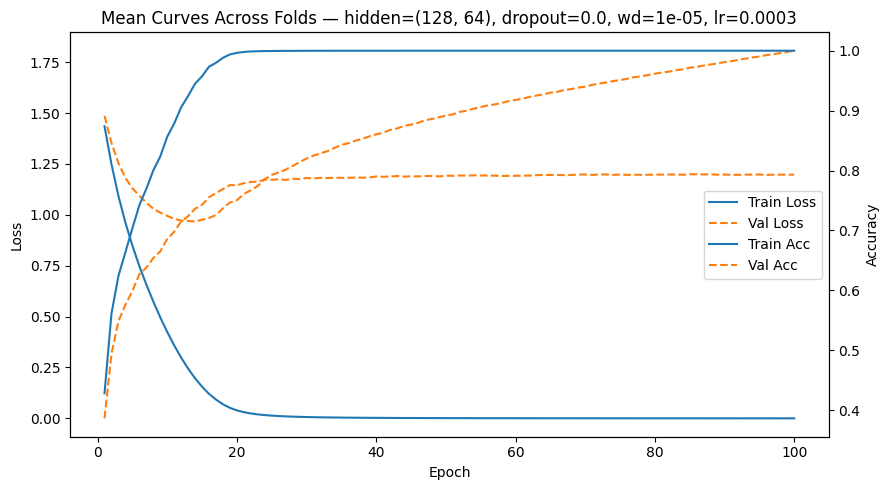

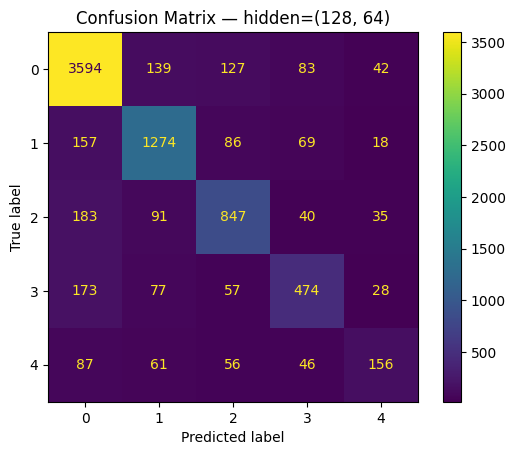


=== Size (256, 128) | Fold 1/5 ===
Class counts: [3188 1283  957  648  324]
              precision    recall  f1-score   support

           0      0.865     0.921     0.892       797
           1      0.790     0.832     0.810       321
           2      0.791     0.778     0.785       239
           3      0.622     0.491     0.549       161
           4      0.608     0.378     0.466        82

    accuracy                          0.811      1600
   macro avg      0.735     0.680     0.700      1600
weighted avg      0.801     0.811     0.803      1600


=== Size (256, 128) | Fold 2/5 ===
Class counts: [3188 1283  957  647  325]
              precision    recall  f1-score   support

           0      0.866     0.922     0.893       797
           1      0.785     0.798     0.791       321
           2      0.737     0.715     0.726       239
           3      0.735     0.617     0.671       162
           4      0.526     0.370     0.435        81

    accuracy                   

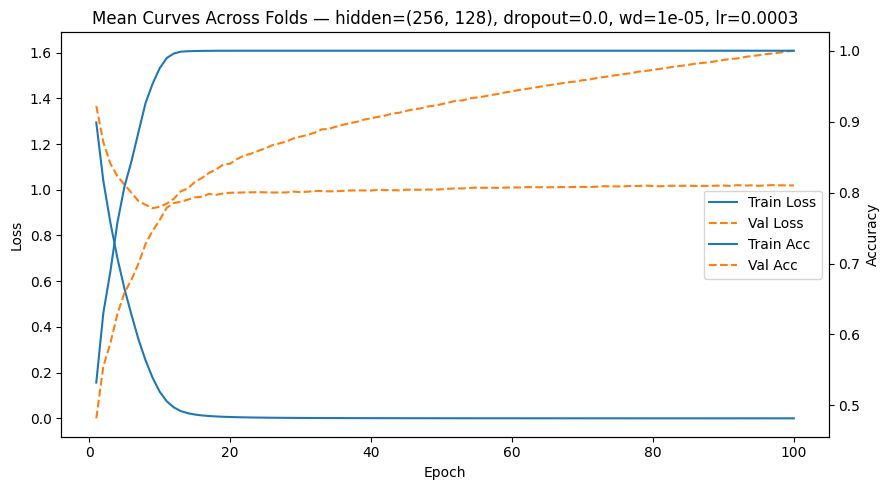

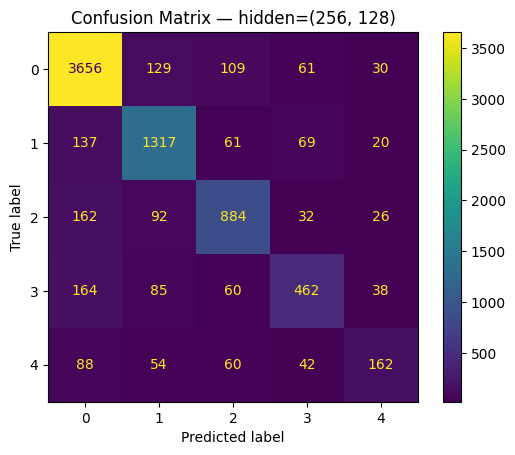


=== Size (512, 256) | Fold 1/5 ===
Class counts: [3188 1283  957  648  324]
              precision    recall  f1-score   support

           0      0.872     0.925     0.898       797
           1      0.802     0.857     0.828       321
           2      0.820     0.762     0.790       239
           3      0.698     0.602     0.647       161
           4      0.647     0.402     0.496        82

    accuracy                          0.828      1600
   macro avg      0.768     0.710     0.732      1600
weighted avg      0.821     0.828     0.822      1600


=== Size (512, 256) | Fold 2/5 ===
Class counts: [3188 1283  957  647  325]
              precision    recall  f1-score   support

           0      0.863     0.918     0.890       797
           1      0.788     0.788     0.788       321
           2      0.730     0.724     0.727       239
           3      0.743     0.623     0.678       162
           4      0.603     0.432     0.504        81

    accuracy                   

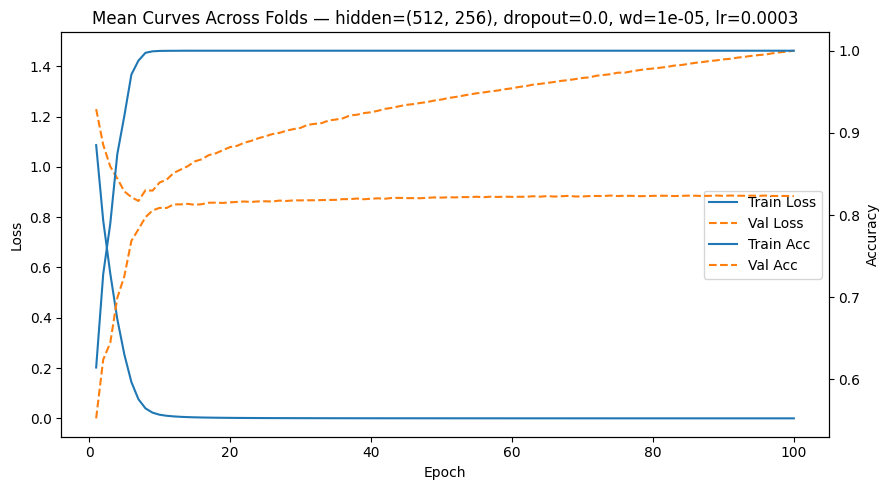

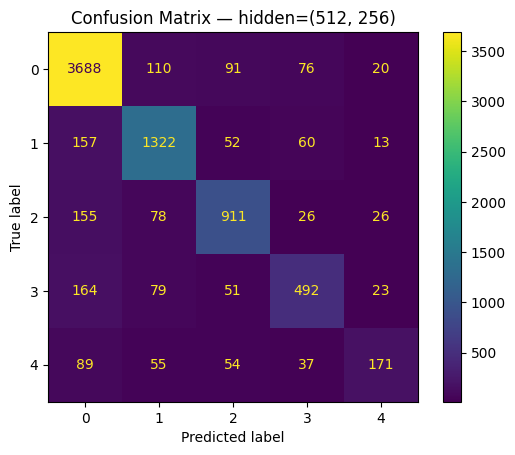


=== Size (1024, 1024) | Fold 1/5 ===
Class counts: [3188 1283  957  648  324]
              precision    recall  f1-score   support

           0      0.869     0.939     0.902       797
           1      0.808     0.850     0.829       321
           2      0.811     0.770     0.790       239
           3      0.754     0.590     0.662       161
           4      0.729     0.427     0.538        82

    accuracy                          0.834      1600
   macro avg      0.794     0.715     0.744      1600
weighted avg      0.829     0.834     0.828      1600


=== Size (1024, 1024) | Fold 2/5 ===
Class counts: [3188 1283  957  647  325]
              precision    recall  f1-score   support

           0      0.869     0.932     0.900       797
           1      0.832     0.832     0.832       321
           2      0.796     0.753     0.774       239
           3      0.779     0.673     0.722       162
           4      0.672     0.481     0.561        81

    accuracy               

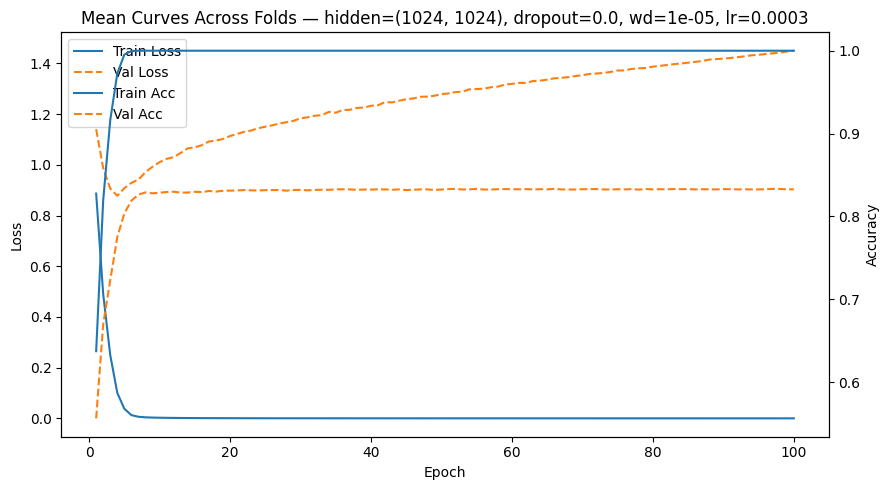

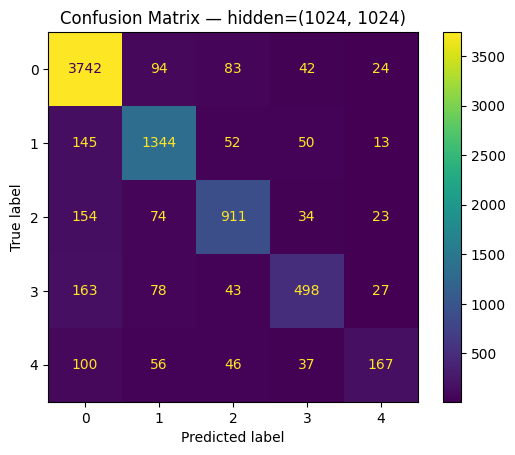


=== Size (2048, 2048) | Fold 1/5 ===
Class counts: [3188 1283  957  648  324]
              precision    recall  f1-score   support

           0      0.887     0.956     0.920       797
           1      0.838     0.869     0.853       321
           2      0.871     0.820     0.845       239
           3      0.798     0.640     0.710       161
           4      0.685     0.451     0.544        82

    accuracy                          0.861      1600
   macro avg      0.816     0.747     0.775      1600
weighted avg      0.856     0.861     0.855      1600


=== Size (2048, 2048) | Fold 2/5 ===
Class counts: [3188 1283  957  647  325]
              precision    recall  f1-score   support

           0      0.910     0.944     0.927       797
           1      0.869     0.888     0.878       321
           2      0.795     0.795     0.795       239
           3      0.807     0.722     0.762       162
           4      0.613     0.469     0.531        81

    accuracy               

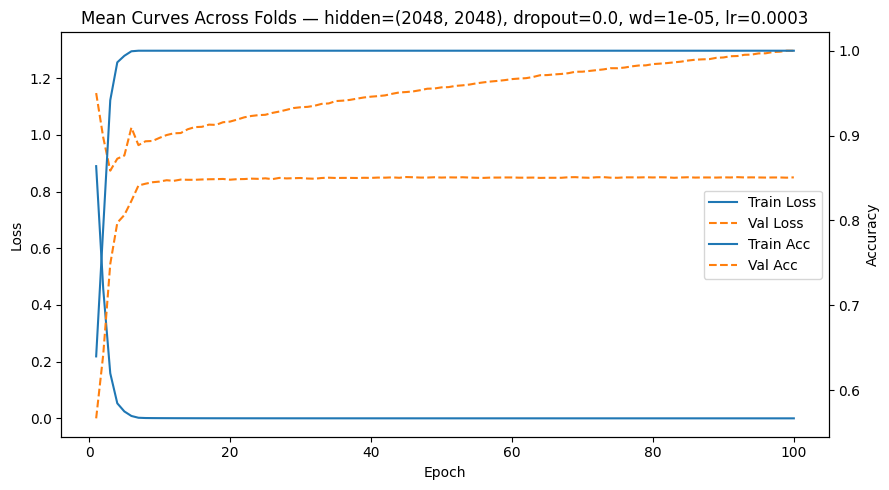

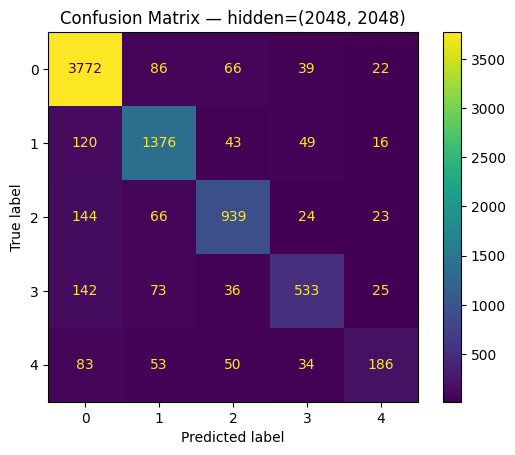

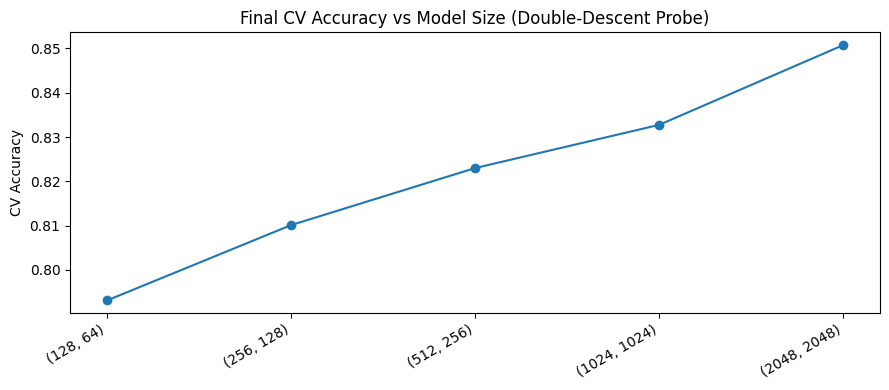

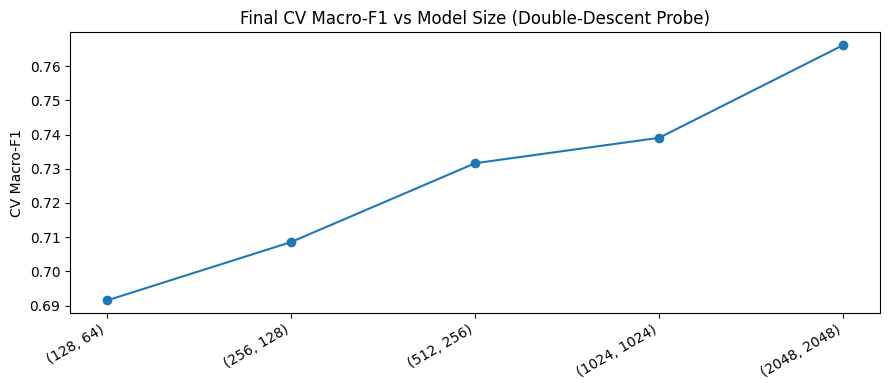


=== Summary ===
hidden=(128, 64): acc=0.7931, macroF1=0.6915
hidden=(256, 128): acc=0.8101, macroF1=0.7086
hidden=(512, 256): acc=0.8230, macroF1=0.7316
hidden=(1024, 1024): acc=0.8327, macroF1=0.7390
hidden=(2048, 2048): acc=0.8508, macroF1=0.7661


In [22]:
"""
Double-descent probe for tabular MLP (Stratified K-Fold CV + StandardScaler per fold)

Goal:
- Try very large MLP widths and see whether validation performance shows "second descent".
- This is an experiment script (not a final tuned model).

Key choices (to make double descent more likely):
- StandardScaler per fold (fit on TRAIN fold only) ✅
- NO early stopping ✅
- Dropout = 0.0 (or very small) ✅
- Weight decay = 1e-5 (very small) ✅
- Label smoothing = 0.0 ✅
- Train long enough to drive training loss near 0 ✅

What you get:
- For each model size:
  - CV-mean train/val loss + accuracy curve (ONE plot per model size)
  - Final cross-validated classification_report + confusion matrix
- Plus a summary plot of final CV mean accuracy vs model size.

IMPORTANT:
- Massive models can be slow / memory-heavy on MPS/GPU.
- If you OOM, reduce batch_size or the biggest hidden size.

Assumptions:
- dataset[i] -> (x, y)
- x is CPU tensor/array; y is scalar class index 0..K-1
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
)
import matplotlib.pyplot as plt


# -----------------------------
# 1) Model
# -----------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, num_classes, hidden=(256, 128), dropout=0.0):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.LayerNorm(h),
                nn.ReLU(),
            ]
            if dropout and dropout > 0:
                layers += [nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, num_classes)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# -----------------------------
# 2) Dataset wrapper
# -----------------------------
class NumpyTabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# -----------------------------
# 3) Helpers
# -----------------------------
def compute_class_weights(y, K, device):
    counts = np.bincount(y, minlength=K)
    weights = counts.sum() / (K * np.maximum(counts, 1))
    return torch.tensor(weights, dtype=torch.float32, device=device), counts


def materialize_numpy(dataset, indices):
    Xs, ys = [], []
    for i in indices:
        x, y = dataset[i]
        if torch.is_tensor(x):
            if x.ndim > 1:
                x = x.view(-1)
            Xs.append(x.detach().cpu().numpy())
        else:
            Xs.append(np.asarray(x).reshape(-1))
        ys.append(int(y.item()) if torch.is_tensor(y) else int(y))
    return np.stack(Xs), np.array(ys, dtype=np.int64)


@torch.no_grad()
def predict_loader(model, loader, device="cpu"):
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        pred = torch.argmax(logits, dim=1).detach().cpu().numpy()
        y_pred.append(pred)
        y_true.append(y.numpy())
    return np.concatenate(y_true), np.concatenate(y_pred)


@torch.no_grad()
def eval_loss_and_acc(model, loader, device, class_w):
    model.eval()
    total_loss = 0.0
    total_n = 0
    all_true, all_pred = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)

        # Use sum reduction for proper dataset mean
        loss_sum = F.cross_entropy(logits, y, weight=class_w, reduction="sum")
        total_loss += float(loss_sum.item())
        total_n += int(y.numel())

        pred = torch.argmax(logits, dim=1)
        all_pred.append(pred.detach().cpu().numpy())
        all_true.append(y.detach().cpu().numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    mean_loss = total_loss / max(total_n, 1)
    acc = accuracy_score(y_true, y_pred) if total_n > 0 else 0.0
    return mean_loss, acc


def plot_mean_curves_across_folds(histories, title):
    """
    histories: list of dicts (one per fold)
      keys: train_loss, val_loss, train_acc, val_acc
    Variable lengths not expected here (no early stopping), but we still support it.
    """
    max_len = max(len(h["train_loss"]) for h in histories)

    def pad(arr, L):
        out = np.full(L, np.nan, dtype=np.float64)
        out[: len(arr)] = np.asarray(arr, dtype=np.float64)
        return out

    tl = np.stack([pad(h["train_loss"], max_len) for h in histories])
    vl = np.stack([pad(h["val_loss"],   max_len) for h in histories])
    ta = np.stack([pad(h["train_acc"],  max_len) for h in histories])
    va = np.stack([pad(h["val_acc"],    max_len) for h in histories])

    tl_m = np.nanmean(tl, axis=0)
    vl_m = np.nanmean(vl, axis=0)
    ta_m = np.nanmean(ta, axis=0)
    va_m = np.nanmean(va, axis=0)

    epochs = np.arange(1, max_len + 1)

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax2 = ax1.twinx()

    ax1.plot(epochs, tl_m, label="Train Loss", linestyle="-")
    ax1.plot(epochs, vl_m, label="Val Loss", linestyle="--")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")

    ax2.plot(epochs, ta_m, label="Train Acc", linestyle="-")
    ax2.plot(epochs, va_m, label="Val Acc", linestyle="--")
    ax2.set_ylabel("Accuracy")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

    plt.title(title)
    plt.tight_layout()
    plt.show()


# -----------------------------
# 4) Train one fold (no early stopping)
# -----------------------------
def train_one_fold(
    train_loader,
    val_loader,
    in_dim,
    K,
    class_w,
    device="cpu",
    hidden=(256, 128),
    dropout=0.0,
    lr=3e-4,
    weight_decay=1e-5,
    epochs=100,
):
    model = MLP(in_dim, K, hidden=hidden, dropout=dropout).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for ep in range(1, epochs + 1):
        model.train()
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = F.cross_entropy(logits, y, weight=class_w)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        tr_loss, tr_acc = eval_loss_and_acc(model, train_loader, device, class_w)
        va_loss, va_acc = eval_loss_and_acc(model, val_loader, device, class_w)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        # You can uncomment to monitor convergence
        # if ep % 10 == 0:
        #     print(f"  Epoch {ep:03d}/{epochs} | tr_loss {tr_loss:.4f} tr_acc {tr_acc:.4f} | va_loss {va_loss:.4f} va_acc {va_acc:.4f}")

    return model, history


# -----------------------------
# 5) CV runner for one model size
# -----------------------------
def cross_validate_one_size(
    dataset,
    hidden=(256, 128),
    dropout=0.0,
    n_splits=5,
    batch_size=128,
    random_state=0,
    device=None,
    epochs=100,
    lr=3e-4,
    weight_decay=1e-5,
    show_plots=True,
):
    if device is None:
        device = "mps" if torch.backends.mps.is_available() else "cpu"

    N = len(dataset)
    indices = np.arange(N)

    y_all = np.array([int(dataset[i][1]) for i in indices], dtype=np.int64)
    K = int(y_all.max()) + 1

    x0, _ = dataset[0]
    in_dim = int(np.prod(x0.shape)) if torch.is_tensor(x0) else int(np.prod(np.asarray(x0).shape))

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    all_true, all_pred = [], []
    all_histories = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(indices, y_all), 1):
        print(f"\n=== Size {hidden} | Fold {fold}/{n_splits} ===")

        # StandardScaler per fold (fit train only)
        X_tr, y_tr = materialize_numpy(dataset, tr_idx)
        X_va, y_va = materialize_numpy(dataset, va_idx)

        scaler = StandardScaler().fit(X_tr)
        X_tr = scaler.transform(X_tr)
        X_va = scaler.transform(X_va)

        train_ds = NumpyTabularDataset(X_tr, y_tr)
        val_ds   = NumpyTabularDataset(X_va, y_va)

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

        class_w, counts = compute_class_weights(y_tr, K, device)
        print("Class counts:", counts)

        model, history = train_one_fold(
            train_loader=train_loader,
            val_loader=val_loader,
            in_dim=in_dim,
            K=K,
            class_w=class_w,
            device=device,
            hidden=hidden,
            dropout=dropout,
            lr=lr,
            weight_decay=weight_decay,
            epochs=epochs,
        )

        all_histories.append(history)

        y_t, y_p = predict_loader(model, val_loader, device=device)
        print(classification_report(y_t, y_p, digits=3, zero_division=0))

        all_true.append(y_t)
        all_pred.append(y_p)

    # aggregate CV results
    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    if show_plots:
        plot_mean_curves_across_folds(
            all_histories,
            title=f"Mean Curves Across Folds — hidden={hidden}, dropout={dropout}, wd={weight_decay}, lr={lr}",
        )

        cm = confusion_matrix(y_true, y_pred)
        ConfusionMatrixDisplay(cm).plot()
        plt.title(f"Confusion Matrix — hidden={hidden}")
        plt.show()

    report = classification_report(y_true, y_pred, digits=3, zero_division=0, output_dict=True)
    cv_acc = report["accuracy"]
    cv_macro_f1 = report["macro avg"]["f1-score"]

    return {
        "hidden": hidden,
        "cv_acc": float(cv_acc),
        "cv_macro_f1": float(cv_macro_f1),
        "y_true": y_true,
        "y_pred": y_pred,
        "histories": all_histories,
    }


# -----------------------------
# 6) Main: try multiple sizes + plot acc vs size
# -----------------------------
def run_double_descent_probe(
    dataset,
    sizes=((128, 64), (256, 128), (512, 256), (1024, 1024), (2048, 2048)),
    dropout=0.0,
    weight_decay=1e-5,
    lr=3e-4,
    epochs=100,
    batch_size=128,
    n_splits=5,
    random_state=0,
    device=None,
):
    results = []
    for hidden in sizes:
        res = cross_validate_one_size(
            dataset=dataset,
            hidden=hidden,
            dropout=dropout,
            n_splits=n_splits,
            batch_size=batch_size,
            random_state=random_state,
            device=device,
            epochs=epochs,
            lr=lr,
            weight_decay=weight_decay,
            show_plots=True,   # one plot per size (curves + confusion matrix)
        )
        results.append(res)

    # Summary plot: accuracy vs size
    labels = [str(r["hidden"]) for r in results]
    accs = [r["cv_acc"] for r in results]
    f1s  = [r["cv_macro_f1"] for r in results]

    plt.figure(figsize=(9, 4))
    plt.plot(np.arange(len(accs)), accs, marker="o")
    plt.xticks(np.arange(len(labels)), labels, rotation=30, ha="right")
    plt.ylabel("CV Accuracy")
    plt.title("Final CV Accuracy vs Model Size (Double-Descent Probe)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.plot(np.arange(len(f1s)), f1s, marker="o")
    plt.xticks(np.arange(len(labels)), labels, rotation=30, ha="right")
    plt.ylabel("CV Macro-F1")
    plt.title("Final CV Macro-F1 vs Model Size (Double-Descent Probe)")
    plt.tight_layout()
    plt.show()

    print("\n=== Summary ===")
    for r in results:
        print(f"hidden={r['hidden']}: acc={r['cv_acc']:.4f}, macroF1={r['cv_macro_f1']:.4f}")

    return results


# -----------------------------
# 7) Run
# -----------------------------
# If you hit OOM with big sizes, reduce batch_size (e.g., 64 or 32) and/or remove (2048,2048).
results = run_double_descent_probe(
    dataset=train_loader.dataset,
    sizes=((128, 64), (256, 128), (512, 256), (1024, 1024), (2048, 2048)),
    dropout=0.0,
    weight_decay=1e-5,
    lr=3e-4,
    epochs=100,
    batch_size=128,
    n_splits=5,
    random_state=0,
)



=== Size (4096, 4096) | Fold 1/5 ===
Class counts: [3188 1283  957  648  324]
              precision    recall  f1-score   support

           0      0.908     0.949     0.928       797
           1      0.851     0.891     0.871       321
           2      0.857     0.824     0.840       239
           3      0.755     0.652     0.700       161
           4      0.597     0.451     0.514        82

    accuracy                          0.863      1600
   macro avg      0.793     0.753     0.770      1600
weighted avg      0.857     0.863     0.859      1600


=== Size (4096, 4096) | Fold 2/5 ===
Class counts: [3188 1283  957  647  325]
              precision    recall  f1-score   support

           0      0.919     0.949     0.933       797
           1      0.858     0.888     0.873       321
           2      0.871     0.791     0.829       239
           3      0.816     0.765     0.790       162
           4      0.592     0.556     0.573        81

    accuracy               

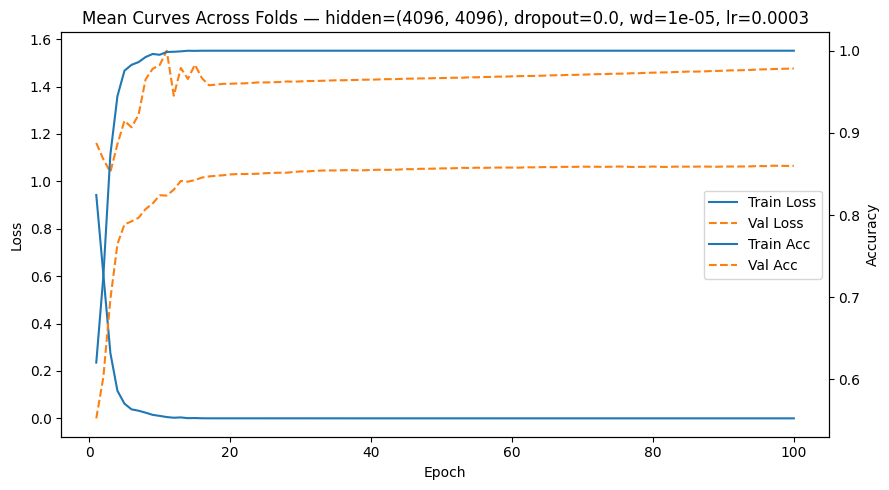

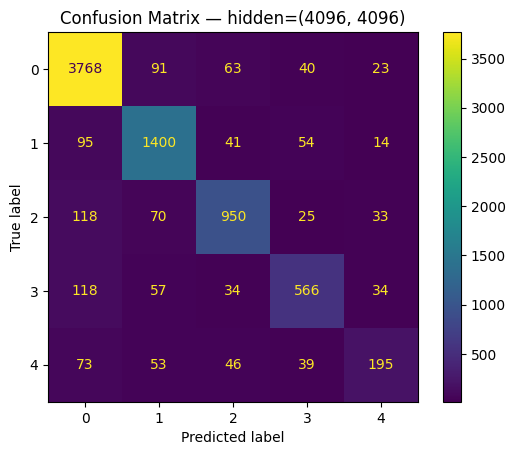


=== Size (8192, 8192) | Fold 1/5 ===
Class counts: [3188 1283  957  648  324]
              precision    recall  f1-score   support

           0      0.898     0.935     0.916       797
           1      0.814     0.875     0.844       321
           2      0.874     0.816     0.844       239
           3      0.726     0.609     0.662       161
           4      0.642     0.524     0.577        82

    accuracy                          0.851      1600
   macro avg      0.791     0.752     0.769      1600
weighted avg      0.847     0.851     0.848      1600


=== Size (8192, 8192) | Fold 2/5 ===
Class counts: [3188 1283  957  647  325]
              precision    recall  f1-score   support

           0      0.902     0.940     0.921       797
           1      0.872     0.850     0.861       321
           2      0.816     0.816     0.816       239
           3      0.791     0.772     0.781       162
           4      0.650     0.481     0.553        81

    accuracy               

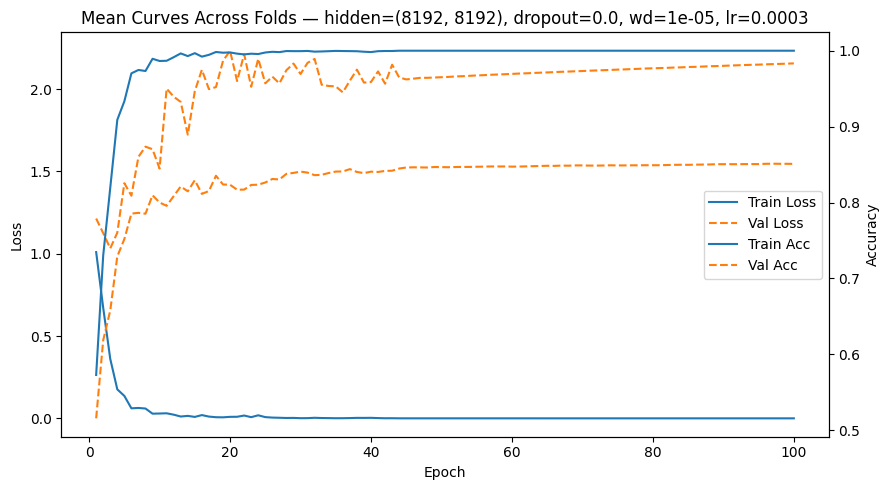

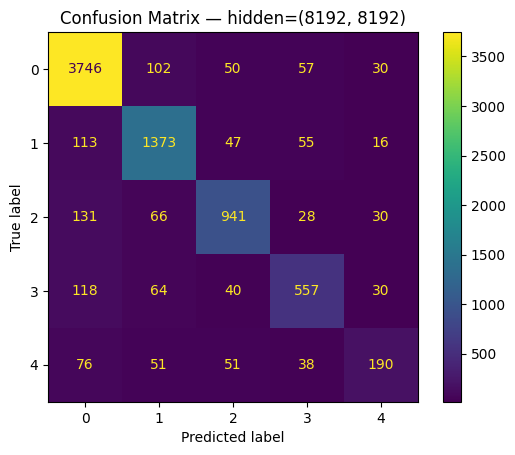


=== Size (16384, 8192, 4096) | Fold 1/5 ===
Class counts: [3188 1283  957  648  324]
              precision    recall  f1-score   support

           0      0.900     0.931     0.915       797
           1      0.856     0.854     0.855       321
           2      0.838     0.841     0.839       239
           3      0.736     0.677     0.706       161
           4      0.618     0.512     0.560        82

    accuracy                          0.855      1600
   macro avg      0.790     0.763     0.775      1600
weighted avg      0.851     0.855     0.853      1600


=== Size (16384, 8192, 4096) | Fold 2/5 ===
Class counts: [3188 1283  957  647  325]
              precision    recall  f1-score   support

           0      0.910     0.937     0.923       797
           1      0.854     0.894     0.874       321
           2      0.824     0.803     0.814       239
           3      0.796     0.698     0.743       162
           4      0.632     0.531     0.577        81

    accuracy 

KeyboardInterrupt: 

In [23]:
"""
Double-descent probe for tabular MLP (Stratified K-Fold CV + StandardScaler per fold)

Goal:
- Try very large MLP widths and see whether validation performance shows "second descent".
- This is an experiment script (not a final tuned model).

Key choices (to make double descent more likely):
- StandardScaler per fold (fit on TRAIN fold only) ✅
- NO early stopping ✅
- Dropout = 0.0 (or very small) ✅
- Weight decay = 1e-5 (very small) ✅
- Label smoothing = 0.0 ✅
- Train long enough to drive training loss near 0 ✅

What you get:
- For each model size:
  - CV-mean train/val loss + accuracy curve (ONE plot per model size)
  - Final cross-validated classification_report + confusion matrix
- Plus a summary plot of final CV mean accuracy vs model size.

IMPORTANT:
- Massive models can be slow / memory-heavy on MPS/GPU.
- If you OOM, reduce batch_size or the biggest hidden size.

Assumptions:
- dataset[i] -> (x, y)
- x is CPU tensor/array; y is scalar class index 0..K-1
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
)
import matplotlib.pyplot as plt


# -----------------------------
# 1) Model
# -----------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, num_classes, hidden=(256, 128), dropout=0.0):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.LayerNorm(h),
                nn.ReLU(),
            ]
            if dropout and dropout > 0:
                layers += [nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, num_classes)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# -----------------------------
# 2) Dataset wrapper
# -----------------------------
class NumpyTabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# -----------------------------
# 3) Helpers
# -----------------------------
def compute_class_weights(y, K, device):
    counts = np.bincount(y, minlength=K)
    weights = counts.sum() / (K * np.maximum(counts, 1))
    return torch.tensor(weights, dtype=torch.float32, device=device), counts


def materialize_numpy(dataset, indices):
    Xs, ys = [], []
    for i in indices:
        x, y = dataset[i]
        if torch.is_tensor(x):
            if x.ndim > 1:
                x = x.view(-1)
            Xs.append(x.detach().cpu().numpy())
        else:
            Xs.append(np.asarray(x).reshape(-1))
        ys.append(int(y.item()) if torch.is_tensor(y) else int(y))
    return np.stack(Xs), np.array(ys, dtype=np.int64)


@torch.no_grad()
def predict_loader(model, loader, device="cpu"):
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        pred = torch.argmax(logits, dim=1).detach().cpu().numpy()
        y_pred.append(pred)
        y_true.append(y.numpy())
    return np.concatenate(y_true), np.concatenate(y_pred)


@torch.no_grad()
def eval_loss_and_acc(model, loader, device, class_w):
    model.eval()
    total_loss = 0.0
    total_n = 0
    all_true, all_pred = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)

        # Use sum reduction for proper dataset mean
        loss_sum = F.cross_entropy(logits, y, weight=class_w, reduction="sum")
        total_loss += float(loss_sum.item())
        total_n += int(y.numel())

        pred = torch.argmax(logits, dim=1)
        all_pred.append(pred.detach().cpu().numpy())
        all_true.append(y.detach().cpu().numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    mean_loss = total_loss / max(total_n, 1)
    acc = accuracy_score(y_true, y_pred) if total_n > 0 else 0.0
    return mean_loss, acc


def plot_mean_curves_across_folds(histories, title):
    """
    histories: list of dicts (one per fold)
      keys: train_loss, val_loss, train_acc, val_acc
    Variable lengths not expected here (no early stopping), but we still support it.
    """
    max_len = max(len(h["train_loss"]) for h in histories)

    def pad(arr, L):
        out = np.full(L, np.nan, dtype=np.float64)
        out[: len(arr)] = np.asarray(arr, dtype=np.float64)
        return out

    tl = np.stack([pad(h["train_loss"], max_len) for h in histories])
    vl = np.stack([pad(h["val_loss"],   max_len) for h in histories])
    ta = np.stack([pad(h["train_acc"],  max_len) for h in histories])
    va = np.stack([pad(h["val_acc"],    max_len) for h in histories])

    tl_m = np.nanmean(tl, axis=0)
    vl_m = np.nanmean(vl, axis=0)
    ta_m = np.nanmean(ta, axis=0)
    va_m = np.nanmean(va, axis=0)

    epochs = np.arange(1, max_len + 1)

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax2 = ax1.twinx()

    ax1.plot(epochs, tl_m, label="Train Loss", linestyle="-")
    ax1.plot(epochs, vl_m, label="Val Loss", linestyle="--")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")

    ax2.plot(epochs, ta_m, label="Train Acc", linestyle="-")
    ax2.plot(epochs, va_m, label="Val Acc", linestyle="--")
    ax2.set_ylabel("Accuracy")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

    plt.title(title)
    plt.tight_layout()
    plt.show()


# -----------------------------
# 4) Train one fold (no early stopping)
# -----------------------------
def train_one_fold(
    train_loader,
    val_loader,
    in_dim,
    K,
    class_w,
    device="cpu",
    hidden=(256, 128),
    dropout=0.0,
    lr=3e-4,
    weight_decay=1e-5,
    epochs=100,
):
    model = MLP(in_dim, K, hidden=hidden, dropout=dropout).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for ep in range(1, epochs + 1):
        model.train()
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = F.cross_entropy(logits, y, weight=class_w)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        tr_loss, tr_acc = eval_loss_and_acc(model, train_loader, device, class_w)
        va_loss, va_acc = eval_loss_and_acc(model, val_loader, device, class_w)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        # You can uncomment to monitor convergence
        # if ep % 10 == 0:
        #     print(f"  Epoch {ep:03d}/{epochs} | tr_loss {tr_loss:.4f} tr_acc {tr_acc:.4f} | va_loss {va_loss:.4f} va_acc {va_acc:.4f}")

    return model, history


# -----------------------------
# 5) CV runner for one model size
# -----------------------------
def cross_validate_one_size(
    dataset,
    hidden=(256, 128),
    dropout=0.0,
    n_splits=5,
    batch_size=128,
    random_state=0,
    device=None,
    epochs=100,
    lr=3e-4,
    weight_decay=1e-5,
    show_plots=True,
):
    if device is None:
        device = "mps" if torch.backends.mps.is_available() else "cpu"

    N = len(dataset)
    indices = np.arange(N)

    y_all = np.array([int(dataset[i][1]) for i in indices], dtype=np.int64)
    K = int(y_all.max()) + 1

    x0, _ = dataset[0]
    in_dim = int(np.prod(x0.shape)) if torch.is_tensor(x0) else int(np.prod(np.asarray(x0).shape))

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    all_true, all_pred = [], []
    all_histories = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(indices, y_all), 1):
        print(f"\n=== Size {hidden} | Fold {fold}/{n_splits} ===")

        # StandardScaler per fold (fit train only)
        X_tr, y_tr = materialize_numpy(dataset, tr_idx)
        X_va, y_va = materialize_numpy(dataset, va_idx)

        scaler = StandardScaler().fit(X_tr)
        X_tr = scaler.transform(X_tr)
        X_va = scaler.transform(X_va)

        train_ds = NumpyTabularDataset(X_tr, y_tr)
        val_ds   = NumpyTabularDataset(X_va, y_va)

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

        class_w, counts = compute_class_weights(y_tr, K, device)
        print("Class counts:", counts)

        model, history = train_one_fold(
            train_loader=train_loader,
            val_loader=val_loader,
            in_dim=in_dim,
            K=K,
            class_w=class_w,
            device=device,
            hidden=hidden,
            dropout=dropout,
            lr=lr,
            weight_decay=weight_decay,
            epochs=epochs,
        )

        all_histories.append(history)

        y_t, y_p = predict_loader(model, val_loader, device=device)
        print(classification_report(y_t, y_p, digits=3, zero_division=0))

        all_true.append(y_t)
        all_pred.append(y_p)

    # aggregate CV results
    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    if show_plots:
        plot_mean_curves_across_folds(
            all_histories,
            title=f"Mean Curves Across Folds — hidden={hidden}, dropout={dropout}, wd={weight_decay}, lr={lr}",
        )

        cm = confusion_matrix(y_true, y_pred)
        ConfusionMatrixDisplay(cm).plot()
        plt.title(f"Confusion Matrix — hidden={hidden}")
        plt.show()

    report = classification_report(y_true, y_pred, digits=3, zero_division=0, output_dict=True)
    cv_acc = report["accuracy"]
    cv_macro_f1 = report["macro avg"]["f1-score"]

    return {
        "hidden": hidden,
        "cv_acc": float(cv_acc),
        "cv_macro_f1": float(cv_macro_f1),
        "y_true": y_true,
        "y_pred": y_pred,
        "histories": all_histories,
    }


# -----------------------------
# 6) Main: try multiple sizes + plot acc vs size
# -----------------------------
def run_double_descent_probe(
    dataset,
    sizes=((128, 64), (256, 128), (512, 256), (1024, 1024), (2048, 2048)),
    dropout=0.0,
    weight_decay=1e-5,
    lr=3e-4,
    epochs=100,
    batch_size=128,
    n_splits=5,
    random_state=0,
    device=None,
):
    results = []
    for hidden in sizes:
        res = cross_validate_one_size(
            dataset=dataset,
            hidden=hidden,
            dropout=dropout,
            n_splits=n_splits,
            batch_size=batch_size,
            random_state=random_state,
            device=device,
            epochs=epochs,
            lr=lr,
            weight_decay=weight_decay,
            show_plots=True,   # one plot per size (curves + confusion matrix)
        )
        results.append(res)

    # Summary plot: accuracy vs size
    labels = [str(r["hidden"]) for r in results]
    accs = [r["cv_acc"] for r in results]
    f1s  = [r["cv_macro_f1"] for r in results]

    plt.figure(figsize=(9, 4))
    plt.plot(np.arange(len(accs)), accs, marker="o")
    plt.xticks(np.arange(len(labels)), labels, rotation=30, ha="right")
    plt.ylabel("CV Accuracy")
    plt.title("Final CV Accuracy vs Model Size (Double-Descent Probe)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.plot(np.arange(len(f1s)), f1s, marker="o")
    plt.xticks(np.arange(len(labels)), labels, rotation=30, ha="right")
    plt.ylabel("CV Macro-F1")
    plt.title("Final CV Macro-F1 vs Model Size (Double-Descent Probe)")
    plt.tight_layout()
    plt.show()

    print("\n=== Summary ===")
    for r in results:
        print(f"hidden={r['hidden']}: acc={r['cv_acc']:.4f}, macroF1={r['cv_macro_f1']:.4f}")

    return results


# -----------------------------
# 7) Run
# -----------------------------
# If you hit OOM with big sizes, reduce batch_size (e.g., 64 or 32) and/or remove (2048,2048).
results = run_double_descent_probe(
    dataset=train_loader.dataset,
    sizes=((4096, 4096), (8192, 8192), (16384, 8192, 4096)),
    dropout=0.0,
    weight_decay=1e-5,
    lr=3e-4,
    epochs=100,
    batch_size=128,
    n_splits=5,
    random_state=0,
)


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# -----------------------------
# 1) FT-Transformer Components
# -----------------------------
class FeatureTokenizer(nn.Module):
    """
    Maps each scalar numerical feature to an embedding vector.
    """
    def __init__(self, in_dim, embed_dim):
        super().__init__()
        # Initializing weights with Kaiming uniform for better gradient flow
        self.weight = nn.Parameter(torch.empty(in_dim, embed_dim))
        self.bias = nn.Parameter(torch.empty(in_dim, embed_dim))
        nn.init.kaiming_uniform_(self.weight)
        nn.init.zeros_(self.bias)

    def forward(self, x):
        # x: [batch, in_dim] -> [batch, in_dim, embed_dim]
        # Broadcasts feature scalar to embedding vector space
        return x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim),
        )
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # Attention with residual connection
        attn_out, _ = self.attention(x, x, x)
        x = self.norm1(x + attn_out)
        # Feed-forward network with residual connection
        x = self.norm2(x + self.ffn(x))
        return x

class FTTransformer(nn.Module):
    def __init__(self, in_dim, num_classes, embed_dim=32, num_heads=8, num_layers=3, dropout=0.2):
        super().__init__()
        self.tokenizer = FeatureTokenizer(in_dim, embed_dim)
        # CLS token acts as the global feature aggregator
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        
        self.layers = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, dropout) for _ in range(num_layers)
        ])
        
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        # 1. Feature Tokenization [B, in_dim] -> [B, in_dim, embed_dim]
        x = self.tokenizer(x)
        
        # 2. Prepend CLS token [B, in_dim + 1, embed_dim]
        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        
        # 3. Stacked Self-Attention Layers
        for layer in self.layers:
            x = layer(x)
            
        # 4. Use output of CLS token for final classification
        return self.head(x[:, 0, :])

# -----------------------------
# 2) Dataset Wrapper
# -----------------------------
class NumpyTabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

def materialize_numpy(dataset, indices):
    Xs, ys = [], []
    for i in indices:
        x, y = dataset[i]
        Xs.append(x.detach().cpu().numpy().flatten())
        ys.append(int(y.item()) if torch.is_tensor(y) else int(y))
    return np.stack(Xs), np.array(ys, dtype=np.int64)

# -----------------------------
# 3) Main Training Loop
# -----------------------------
def cross_validate_transformer(dataset, epochs=30):
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    y_all = np.array([int(dataset[i][1]) for i in range(len(dataset))])
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    
    all_true, all_pred = [], []
    
    for fold, (tr_idx, va_idx) in enumerate(skf.split(np.zeros(len(y_all)), y_all), 1):
        print(f"=== Fold {fold} ===")
        X_tr_raw, y_tr = materialize_numpy(dataset, tr_idx)
        X_va_raw, y_va = materialize_numpy(dataset, va_idx)
        
        scaler = StandardScaler().fit(X_tr_raw)
        X_tr, X_va = scaler.transform(X_tr_raw), scaler.transform(X_va_raw)
        
        # DYNAMIC INFERENCE: Resolve the 205 vs 206 feature dimension conflict
        input_dim = X_tr.shape[1] 

        train_loader = DataLoader(NumpyTabularDataset(X_tr, y_tr), batch_size=128, shuffle=True)
        
        model = FTTransformer(in_dim=input_dim, num_classes=int(y_all.max())+1).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
        
        for ep in range(epochs):
            model.train()
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                optimizer.zero_grad()
                loss = F.cross_entropy(model(x), y)
                loss.backward()
                optimizer.step()
        
        model.eval()
        with torch.no_grad():
            val_tensor = torch.from_numpy(X_va.astype(np.float32)).to(device)
            preds = torch.argmax(model(val_tensor), dim=1)
            all_true.append(y_va)
            all_pred.append(preds.cpu().numpy())

    y_true, y_pred = np.concatenate(all_true), np.concatenate(all_pred)
    print("\nFT-Transformer Cross-Validated Results:\n")
    print(classification_report(y_true, y_pred, digits=3))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    plt.show()

if __name__ == "__main__":
    # Ensure train_loader.dataset exists in your environment
    cross_validate_transformer(train_loader.dataset)

=== Fold 1 ===
